In [1]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from blended_learning.config.settings import settings
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import prince



In [2]:
df = pd.read_csv(settings.path['output_cleaned_path'])

In [3]:
df.head(n=2)

,gender,age,is_itc_student,itc_campus,province,itc_student_id,education_level,department,faculty,academic_year,...,career_preparation,ideal_balance,prefer_more_blended,open_strengths,open_challenges_suggestions,survey_start,survey_end,response_time_minutes,student_id,flag_speeder
0,Male,36,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20210528,Year5 - Final Year,GIC,NaN,2021–2022,...,2,"More Online than Face-to-Face (e.g., 40% In-pe...",No,NaN,NaN,2026-03-12 00:35:35.641,2026-03-12 00:37:43.468,2.130450,e20210528,True
1,Male,23,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20210686,Year5 - Final Year,GIC,NaN,2025–2026,...,3,"More Online than Face-to-Face (e.g., 40% In-pe...",Neutral/Unsure,Nothing,Nothing,2026-03-17 18:53:40.435,2026-03-17 18:56:16.257,2.597033,e20210686,True


In [4]:
cluster_vars = list(settings.ordinal_column_scales.keys())
multi_groups = dict(settings.multi_select_cols)
pretty_label = dict(settings.pretty_print_columns)
RANDOM_STATE = 42

## 1. K Modes

In [5]:
# ── K-Modes input preparation ────────────────────────────────────────────────
X_km = df[cluster_vars].copy()

print('Input shape:', X_km.shape)
print('Total nulls :', X_km.isna().sum().sum())

if X_km.isna().sum().sum() > 0:
    raise ValueError('CLUSTER_VARS contains missing values. Clean or impute before K-Modes.')

for c in X_km.columns:
    X_km[c] = X_km[c].astype('Int64').astype(str)

print('\nSample encoded values:')
display(X_km.head())

# final matrix passed to K-Modes
X_km_fit = X_km.to_numpy()

Input shape: (588, 33)
Total nulls : 0

Sample encoded values:


,use_lecture_slides,use_video_lectures,use_quizzes,use_articles,use_forums,use_simulations,online_discussion_participation,peer_collaboration,comfort_asking_questions,sense_of_community,...,digital_literacy_improvement,tech_issues_freq,lms_usability,overall_satisfaction,benefit_flexibility,benefit_variety,benefit_recorded_access,benefit_self_study_time,benefit_life_balance,benefit_self_directed
0,1,2,3,4,5,1,3,2,4,3,...,1,2,3,4,4,3,5,2,1,2
1,3,3,3,4,4,4,3,4,3,4,...,4,3,3,4,3,4,4,4,1,4
2,4,4,4,3,4,4,4,4,3,3,...,5,3,4,4,4,3,4,4,3,5
3,5,5,3,3,3,3,3,3,3,3,...,4,4,4,3,3,3,4,4,4,4
4,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3


In [6]:
# ── K-Modes elbow search ────────────────────────────────
K_RANGE_ELBOW = range(1, 7)
N_RUNS = 10

km_elbow_results = []

for k in K_RANGE_ELBOW:
    costs = []

    for seed in range(N_RUNS):
        km = KModes(
            n_clusters=k,
            init='Huang' if k > 1 else 'Cao',
            n_init=5,
            random_state=seed,
            verbose=0
        )
        km.fit_predict(X_km_fit)
        costs.append(km.cost_)

    km_elbow_results.append({
        'k': k,
        'best_cost': np.min(costs),
        'mean_cost': np.mean(costs),
        'sd_cost': np.std(costs)
    })

km_elbow_df = pd.DataFrame(km_elbow_results)
display(km_elbow_df.round(4))

,k,best_cost,mean_cost,sd_cost
0,1,10677.0,10677.0,0.0000
1,2,9110.0,9110.9,2.7000
2,3,8752.0,8789.9,24.3165
3,4,8432.0,8525.5,59.5806
4,5,8265.0,8303.3,35.2138
5,6,8115.0,8156.8,27.6724


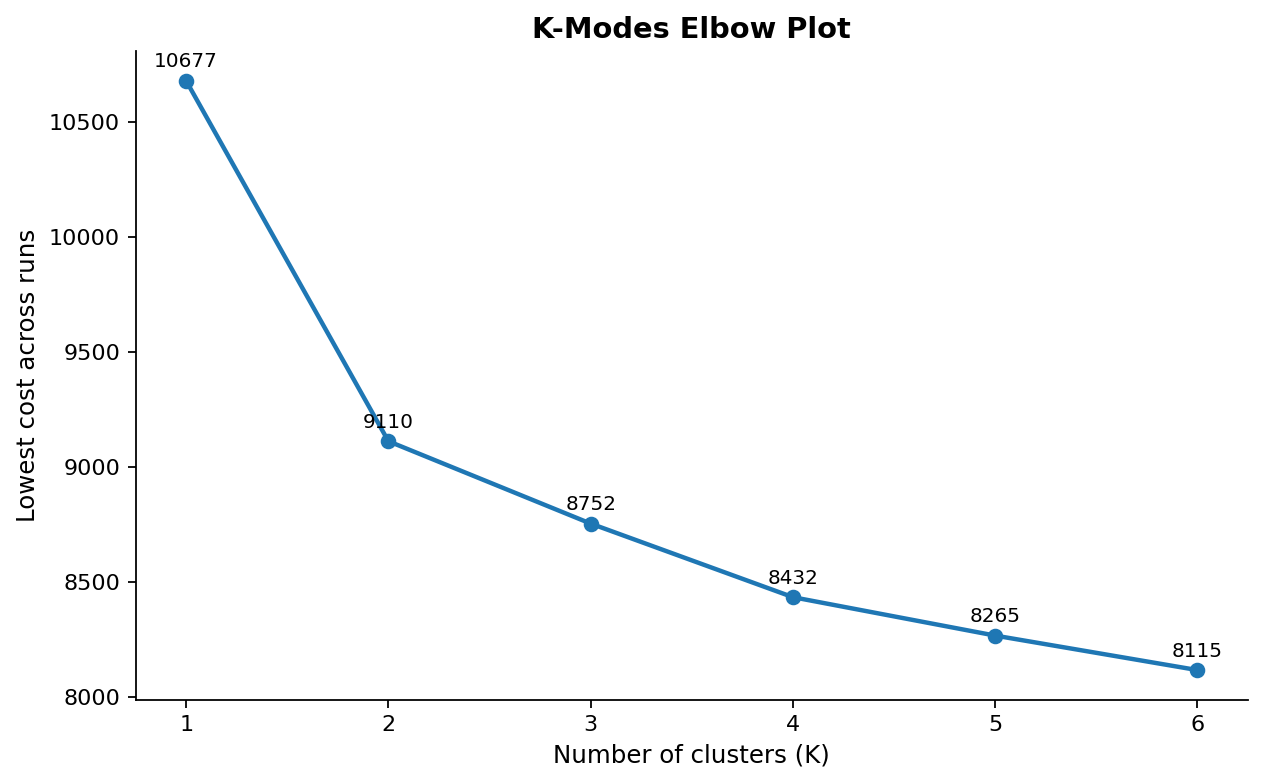

In [7]:
# ── 6.4B K-Modes elbow figure ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), dpi=160)

ax.plot(km_elbow_df['k'], km_elbow_df['best_cost'], marker='o', linewidth=2)

ax.set_title('K-Modes Elbow Plot', fontsize=13, weight='bold')
ax.set_xlabel('Number of clusters (K)', fontsize=11)
ax.set_ylabel('Lowest cost across runs', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

for xi, yi in zip(km_elbow_df['k'], km_elbow_df['best_cost']):
    ax.annotate(f'{yi:.0f}', (xi, yi), textcoords='offset points', xytext=(0, 6),
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
#  K-Modes diagnostics search  ──────────────────────────────
from sklearn.metrics import silhouette_score, normalized_mutual_info_score

K_RANGE_DIAG = range(2, 7)
N_RUNS = 10

# Numeric-coded copy used only for Hamming silhouette evaluation.
# This does not change the categorical K-Modes fitting input.
X_km_eval = X_km.apply(lambda col: pd.Categorical(col).codes)

km_diag_results = []

for k in K_RANGE_DIAG:
    labels_runs = []
    costs = []
    sils = []

    for seed in range(N_RUNS):
        km = KModes(
            n_clusters=k,
            init='Huang',
            n_init=5,
            random_state=seed,
            verbose=0
        )

        labels = km.fit_predict(X_km_fit)

        labels_runs.append(labels)
        costs.append(km.cost_)

        # Supporting diagnostic only
        sil = silhouette_score(X_km_eval, labels, metric='hamming')
        sils.append(sil)

    # Pairwise NMI across runs as a stability diagnostic
    nmis = []
    for i in range(len(labels_runs)):
        for j in range(i + 1, len(labels_runs)):
            nmis.append(normalized_mutual_info_score(labels_runs[i], labels_runs[j]))

    # Cluster balance from the best-cost run
    best_idx = int(np.argmin(costs))
    best_labels = labels_runs[best_idx]
    counts = np.bincount(best_labels, minlength=k)

    km_diag_results.append({
        'k': k,
        'mean_silhouette': np.mean(sils),
        'sd_silhouette': np.std(sils),
        'mean_nmi': np.mean(nmis),
        'sd_nmi': np.std(nmis),
        'min_cluster_size': counts.min(),
        'max_cluster_size': counts.max(),
        'balance_ratio': counts.min() / counts.max()
    })

km_diag_df = pd.DataFrame(km_diag_results)

print('K-Modes diagnostics search complete.')
display(km_diag_df.round(4))

K-Modes diagnostics search complete.


,k,mean_silhouette,sd_silhouette,mean_nmi,sd_nmi,min_cluster_size,max_cluster_size,balance_ratio
0,2,0.1232,0.0005,0.8818,0.0987,251,337,0.7448
1,3,0.0809,0.0084,0.4110,0.0984,109,317,0.3438
2,4,0.0723,0.0099,0.3980,0.0694,69,272,0.2537
3,5,0.0632,0.0096,0.4175,0.0545,51,194,0.2629
4,6,0.0579,0.0073,0.3976,0.0375,41,158,0.2595


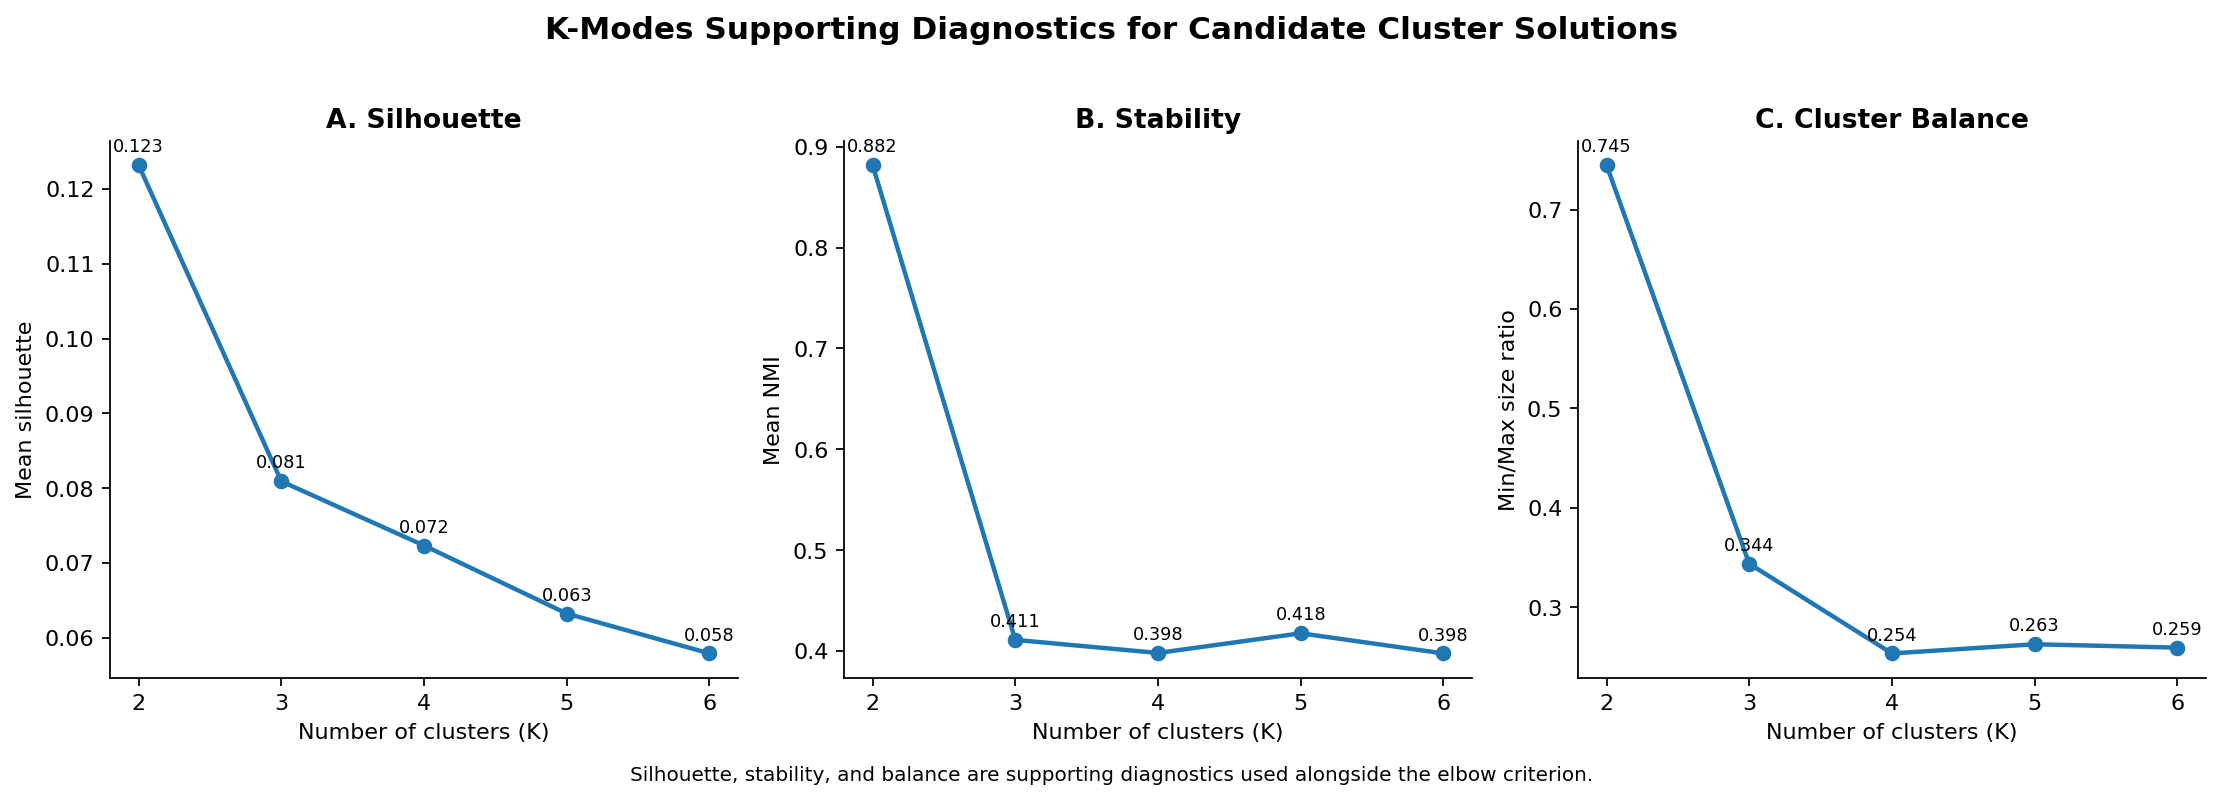

In [9]:
# ──  K-Modes diagnostics figure 
from matplotlib.ticker import FormatStrFormatter

k_vals = km_diag_df['k'].tolist()
# k_best = 2 

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), dpi=160)
fig.patch.set_facecolor('white')

def style_ax(ax):
    ax.set_xticks(k_vals)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis='both', labelsize=10)

def annotate_points(ax, x, y, fmt):
    for xi, yi in zip(x, y):
        ax.annotate(
            fmt.format(yi),
            (xi, yi),
            textcoords='offset points',
            xytext=(0, 6),
            ha='center',
            fontsize=8
        )

# A. Mean silhouette
ax = axes[0]
ax.plot(km_diag_df['k'], km_diag_df['mean_silhouette'], marker='o', linewidth=2)
style_ax(ax)
# add_k_line(ax, k_best)
annotate_points(ax, km_diag_df['k'], km_diag_df['mean_silhouette'], '{:.3f}')
ax.set_title('A. Silhouette', fontsize=12, weight='bold')
ax.set_xlabel('Number of clusters (K)', fontsize=10)
ax.set_ylabel('Mean silhouette', fontsize=10)

# B. Mean Normalized Mutual Information (NMI) 
# measures the agreement between cluster assignments obtained
# from different runs, with higher values indicating greater solution stability.
ax = axes[1]
ax.plot(km_diag_df['k'], km_diag_df['mean_nmi'], marker='o', linewidth=2)
style_ax(ax)
# add_k_line(ax, k_best)
annotate_points(ax, km_diag_df['k'], km_diag_df['mean_nmi'], '{:.3f}')
ax.set_title('B. Stability', fontsize=12, weight='bold')
ax.set_xlabel('Number of clusters (K)', fontsize=10)
ax.set_ylabel('Mean NMI', fontsize=10)

# C. Balance ratio
ax = axes[2]
ax.plot(km_diag_df['k'], km_diag_df['balance_ratio'], marker='o', linewidth=2)
style_ax(ax)
# add_k_line(ax, k_best)
annotate_points(ax, km_diag_df['k'], km_diag_df['balance_ratio'], '{:.3f}')
ax.set_title('C. Cluster Balance', fontsize=12, weight='bold')
ax.set_xlabel('Number of clusters (K)', fontsize=10)
ax.set_ylabel('Min/Max size ratio', fontsize=10)

fig.suptitle(
    'K-Modes Supporting Diagnostics for Candidate Cluster Solutions',
    fontsize=14,
    weight='bold',
    y=1.02
)

fig.text(
    0.5, -0.02,
    'Silhouette, stability, and balance are supporting diagnostics used alongside the elbow criterion.',
    ha='center',
    fontsize=9
)

plt.tight_layout()
plt.show()

In [10]:
# ── Final K-Modes fit (main segmentation model) ──────────────────────────
K_KMODES = 2   # change to 3 only if you finally justify K=3

km_final = KModes(
    n_clusters=K_KMODES,
    init='Huang',
    n_init=10,
    # random_state=RANDOM_STATE,
    random_state=43,
    verbose=0
)
idx = df.index
km_labels = km_final.fit_predict(X_km_fit) + 1   # 1-indexed labels

print(f"K-Modes final model  K={K_KMODES}")
for cid in sorted(np.unique(km_labels)):
    n = (km_labels == cid).sum()
    print(f"  Cluster {cid}: {n} students ({n/len(km_labels)*100:.1f}%)")

# store final main segment labels
df.loc[idx, 'student_segment'] = km_labels

K-Modes final model  K=2
  Cluster 1: 357 students (60.7%)
  Cluster 2: 231 students (39.3%)


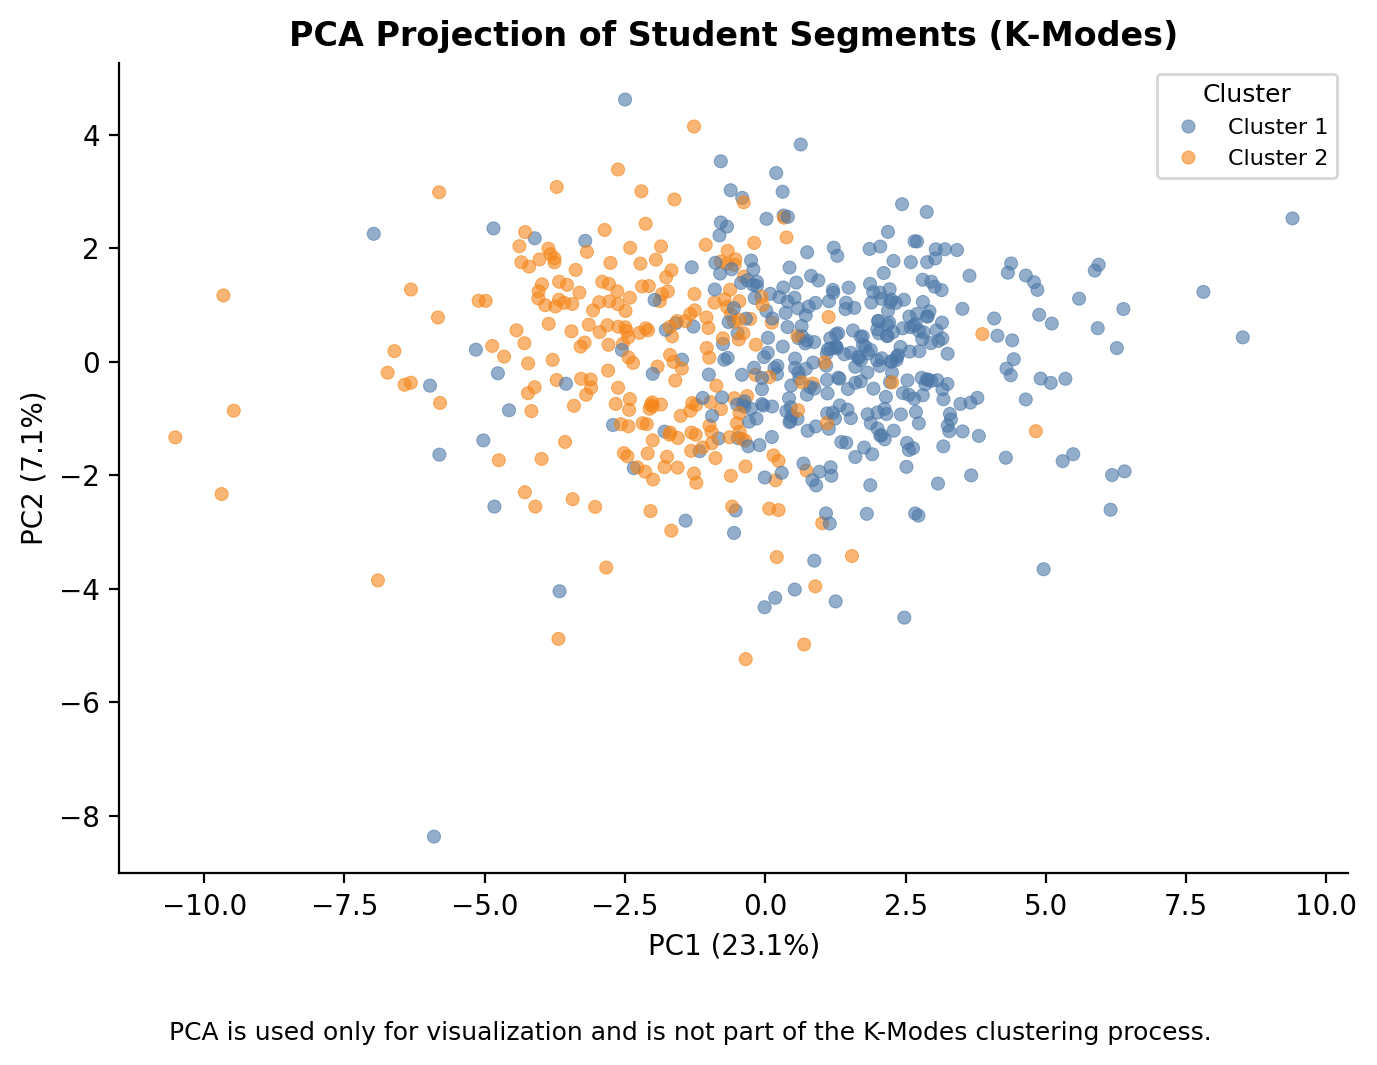

In [11]:
# ── PCA projection for K-Modes only 
# 1. Prepare data
X_pca_vis = df[cluster_vars].copy().dropna()
idx_vis = X_pca_vis.index

scaler = StandardScaler()
X_pca_sc = scaler.fit_transform(X_pca_vis)

# PCA
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2.fit_transform(X_pca_sc)

# Clean K-Modes labels only
km_labels_clean = df.loc[idx_vis, 'student_segment'].astype(int).map({
    1: 'Cluster 1',
    2: 'Cluster 2'
})

# DataFrame
vis_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'Cluster': km_labels_clean
})

palette = {
    'Cluster 1': '#4C78A8',
    'Cluster 2': '#F58518'
}

cluster_order = ['Cluster 1', 'Cluster 2']

# ── Plot ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5), dpi=200)

sns.scatterplot(
    data=vis_df,
    x='PC1', y='PC2',
    hue='Cluster',
    hue_order=cluster_order,
    palette=palette,
    s=22,
    alpha=0.60,
    edgecolor=None,
    ax=ax
)

ax.set_title('PCA Projection of Student Segments (K-Modes)', fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    title='Cluster',
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

# footnote
fig.text(
    0.5, -0.05,
    'PCA is used only for visualization and is not part of the K-Modes clustering process.',
    ha='center', fontsize=9
)

plt.tight_layout()
plt.show()

#### 1.3 post-hoc cluster profiling

#### Compare age by cluster

In [12]:
df["student_segment"] = df["student_segment"].astype(int)
df["student_segment"].unique()

array([1, 2])

In [13]:
df.groupby("student_segment")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
student_segment,,,,,,,,
1,357.0,20.372549,2.531515,17.0,19.0,20.0,21.0,43.0
2,231.0,20.203463,1.795450,17.0,19.0,20.0,21.0,29.0


Both clusters have almost the same average age, so age is not an important factor separating the two groups.

In [14]:
df.groupby("student_segment")["age"].mean().round(2)

student_segment
1    20.37
2    20.20
Name: age, dtype: float64

Interpretation:

The mean age of students in Segment 1 was 20.63 years, compared with 20.39 years in Segment 2. This small difference suggests that age is relatively similar across the two clusters and does not appear to be a major differentiating factor between student segments.

#### Compare categorical variables by cluster

By Gender

In [15]:
pd.crosstab(df["student_segment"], df["gender"], normalize="index") * 100

gender,Female,Male,Prefer Not To Say
student_segment,,,
1,32.773109,65.546218,1.680672
2,32.467532,66.233766,1.298701


Interpretation


Both clusters are male-dominated, and the proportions of male and female students are nearly the same in both groups. The differences are very small:

Male difference: about 1.5 percentage points
Female difference: about 1 percentage point

This suggests that gender does not meaningfully differentiate the two student segments.

By education_level

In [16]:
pd.crosstab(df["student_segment"], df["education_level"], normalize="index") * 100

education_level,Master,Other,PHD,Year1 - Freshman,Year2 - Sophomore,Year3 - Junior,Year4 - Senior,Year5 - Final Year
student_segment,,,,,,,,
1,4.201681,1.400560,0.280112,3.361345,50.700280,15.966387,14.285714,9.803922
2,2.597403,2.597403,0.000000,4.761905,55.411255,13.852814,12.554113,8.225108


By department

In [17]:
pd.crosstab(df["student_segment"], df["department"], normalize="index") * 100

department,AMS,Foundation Year,GAR,GCA,GCI,GEE,GIC,GIM,GRU,GTI,GTR,Graduate School,Other
student_segment,,,,,,,,,,,,,
1,37.278107,8.284024,4.437870,0.295858,1.479290,10.946746,18.343195,7.396450,4.437870,0.295858,4.142012,0.887574,1.775148
2,17.808219,11.872146,11.415525,0.913242,2.283105,10.045662,23.287671,11.872146,5.022831,0.000000,4.109589,0.456621,0.913242


By itc_campus

In [18]:
pd.crosstab(df["student_segment"], df["itc_campus"], normalize="index") * 100

itc_campus,ITC Kep Campus,ITC Phnom Penh (Main Campus)
student_segment,,
1,0.295858,99.704142
2,0.000000,100.000000


By prefer_more_blended 

In [19]:
pd.crosstab(df["student_segment"], df["prefer_more_blended"], normalize="index") * 100

prefer_more_blended,Neutral/Unsure,No,Yes
student_segment,,,
1,29.691877,3.641457,66.666667
2,58.874459,6.060606,35.064935


By ideal_balance

In [20]:
pd.crosstab(df["student_segment"], df["ideal_balance"], normalize="index") * 100

ideal_balance,"Balanced Half and Half (50% In-person, 50% Online)","More Face-to-Face than Online (e.g., 60% In-person, 40% Online)","More Online than Face-to-Face (e.g., 40% In-person, 60% Online)","Mostly Face-to-Face (e.g., 80% In-person, 20% Online)","Mostly Online (e.g., 20% In-person, 80% Online)"
student_segment,,,,,
1,21.008403,30.812325,6.722689,38.375350,3.081232
2,21.212121,25.541126,5.627706,44.588745,3.030303


By enrollment_status

In [21]:
pd.crosstab(df["student_segment"], df["enrollment_status"], normalize="index") * 100

enrollment_status,Currently enrolled,Not currently enrolled,On academic leave,Recently graduated
student_segment,,,,
1,79.551821,2.801120,13.445378,4.201681
2,78.354978,4.329004,10.389610,6.926407


#### Compare ordinal categorical variables by cluster

In [22]:
pd.crosstab(df["student_segment"], df["social_media_hours"], normalize="index") * 100

social_media_hours,1 Hour,2 hours,3 hours,4 hours,Less than 1 hour,More than 5 hours
student_segment,,,,,,
1,13.165266,23.249300,27.170868,17.086835,6.442577,12.885154
2,12.987013,27.705628,19.480519,15.584416,4.329004,19.913420


In [23]:
pd.crosstab(df["student_segment"], df["academic_year"], normalize="index") * 100

academic_year,2019–2020,2020–2021,2021–2022,2022–2023,2023–2024,2024–2025,2025–2026
student_segment,,,,,,,
1,0.280112,0.560224,2.801120,3.921569,3.921569,23.249300,65.266106
2,0.432900,2.164502,2.164502,5.627706,6.493506,23.809524,59.307359


#### Compare binary multi-select variables by cluster

In [24]:
challenge_cols = multi_groups["challenges"]

(df.groupby("student_segment")[challenge_cols].mean() * 100).round(1)

,ch_internet,ch_no_instructor_support,ch_motivation,ch_limited_interaction,ch_time_management,ch_isolation,ch_misunderstanding,ch_delayed_feedback,ch_asking_questions,ch_info_overload,ch_other
student_segment,,,,,,,,,,,
1,72.5,41.2,51.5,34.5,26.6,21.6,31.7,23.0,37.8,21.3,1.7
2,70.6,39.0,52.4,35.9,26.4,26.8,32.0,23.4,35.1,25.5,0.9


In [25]:
challenge_cols = multi_groups["devices"]

(df.groupby("student_segment")[challenge_cols].mean() * 100).round(1)

,device_mobile,device_tablet,device_laptop,device_desktop,device_other
student_segment,,,,,
1,82.9,35.3,85.4,10.4,0.6
2,84.8,27.3,84.4,11.3,0.4


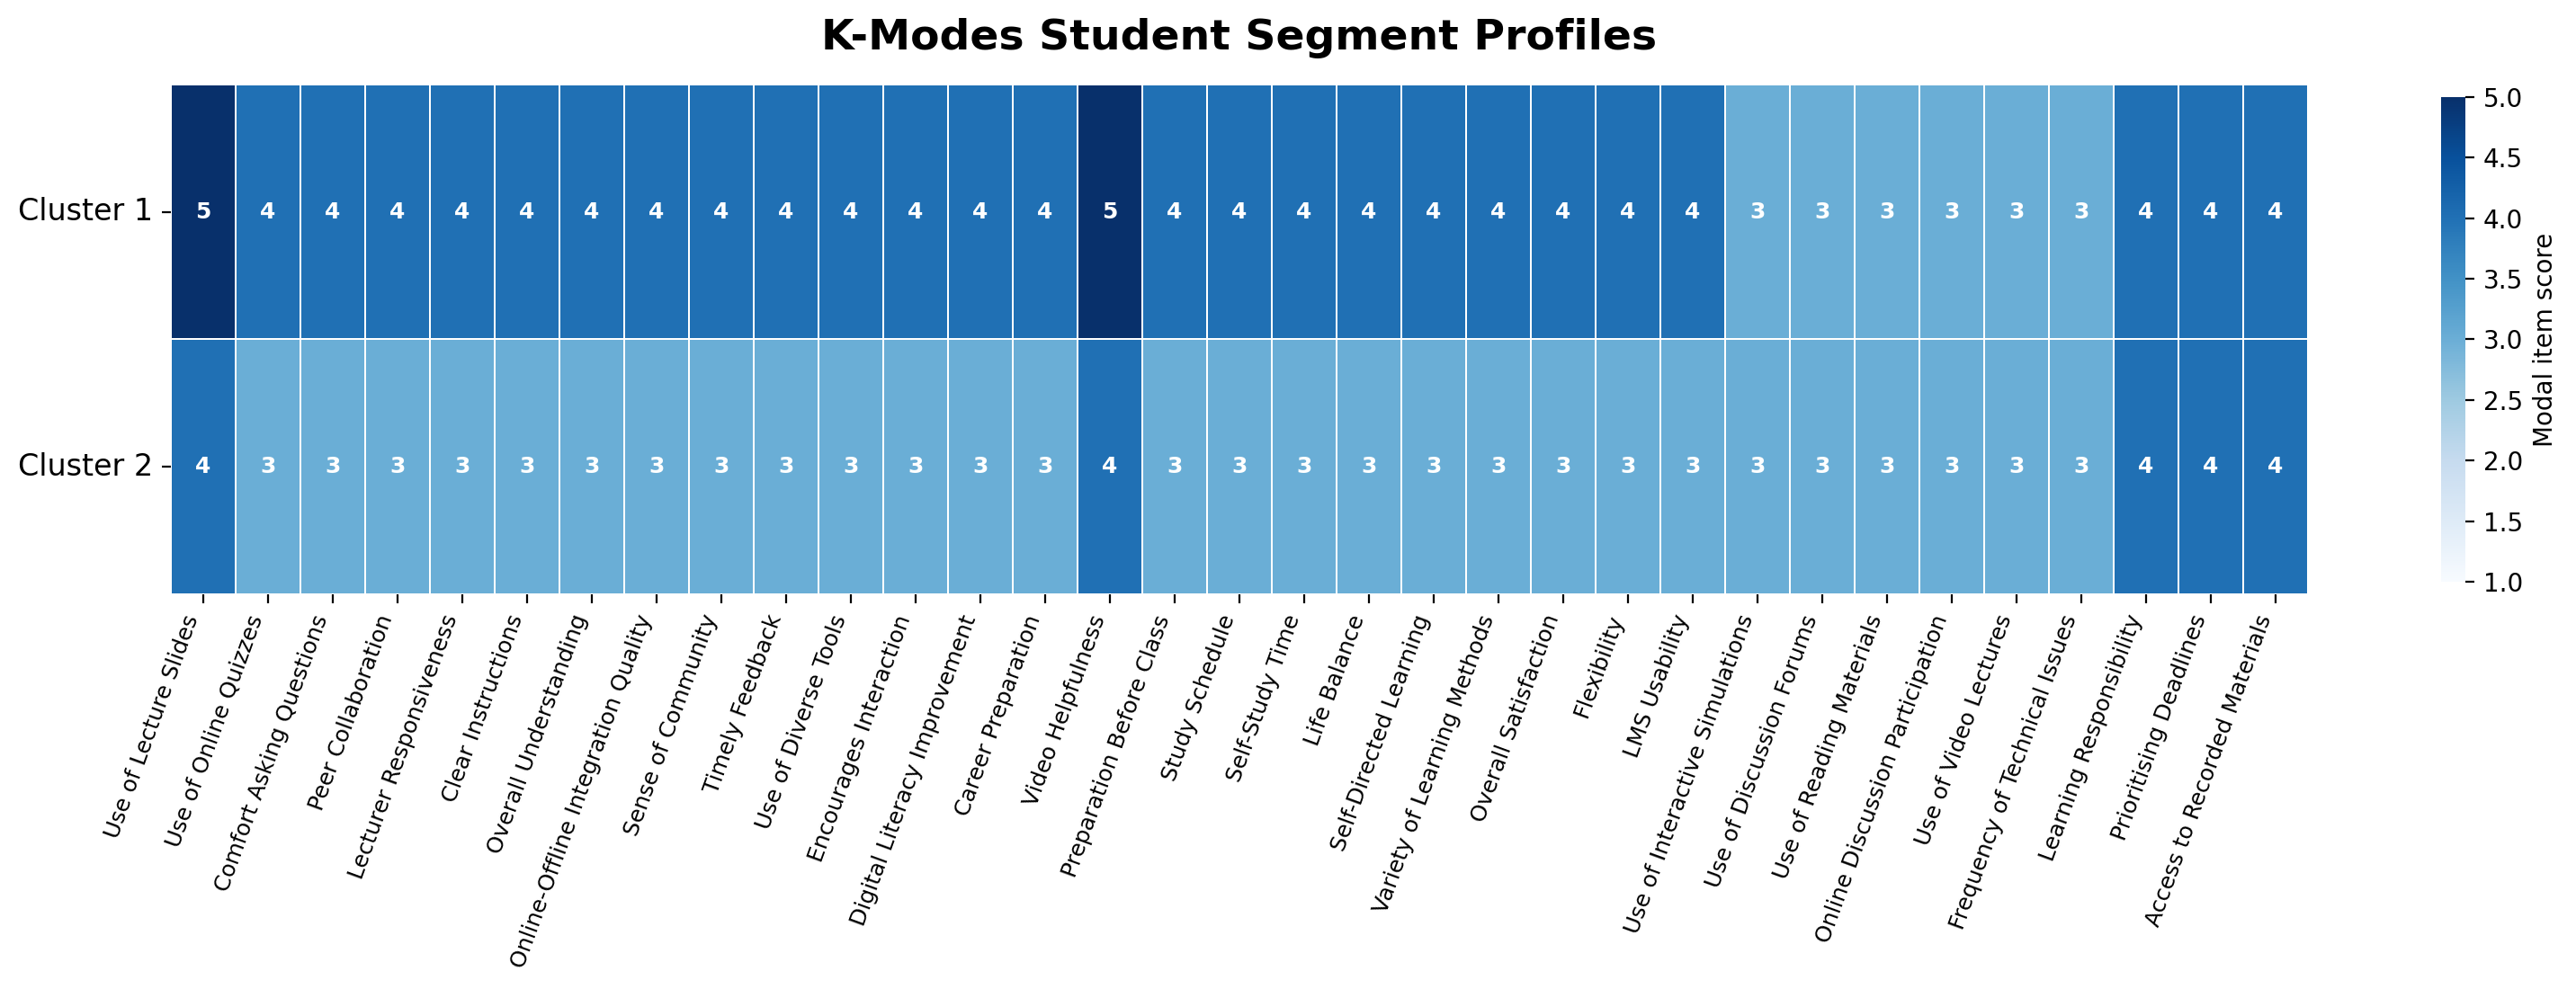

In [26]:
km_profile = (
    df.assign(student_segment=km_labels)
      .groupby('student_segment')[cluster_vars]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Label rows
km_profile.index = [f'Cluster {i}' for i in km_profile.index]

# Order variables by difference between clusters
if km_profile.shape[0] == 2:
    diff_order = (km_profile.iloc[0] - km_profile.iloc[1]).abs().sort_values(ascending=False).index
else:
    diff_order = km_profile.var(axis=0).sort_values(ascending=False).index

km_profile_plot = km_profile[diff_order].copy()
display_cols_ordered = [pretty_label.get(c, c.replace('_', ' ').title()) for c in km_profile_plot.columns]

# Plot main heatmap with annotations
plt.figure(figsize=(16, 5.6), dpi=200)
ax = sns.heatmap(
    km_profile_plot,
    cmap='Blues',
    vmin=1, vmax=5,
    annot=True,                 # show values
    fmt='.0f',                  # integer format (no decimals)
    annot_kws={'size': 9, 'weight': 'bold'},
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': 'Modal item score', 'shrink': 0.95}
)

ax.set_title('K-Modes Student Segment Profiles', fontsize=17, weight='bold', pad=14)
ax.set_xlabel('')
ax.set_ylabel('')

ax.set_xticklabels(display_cols_ordered, rotation=70, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

In [27]:
cluster_name_map = {
    1: "Highly Engaged (Active) Learners",
    2: "Moderately Engaged (Passive) Learners"
}

df["student_segment_label"] = df["student_segment"].map(cluster_name_map)

df[["student_segment", "student_segment_label"]].head()

,student_segment,student_segment_label
0,1,Highly Engaged (Active) Learners
1,2,Moderately Engaged (Passive) Learners
2,1,Highly Engaged (Active) Learners
3,1,Highly Engaged (Active) Learners
4,2,Moderately Engaged (Passive) Learners


CLUSTER_LABEL_MAP:
  1 -> Highly Engaged (Active) Learners
  2 -> Moderately Engaged (Passive) Learners


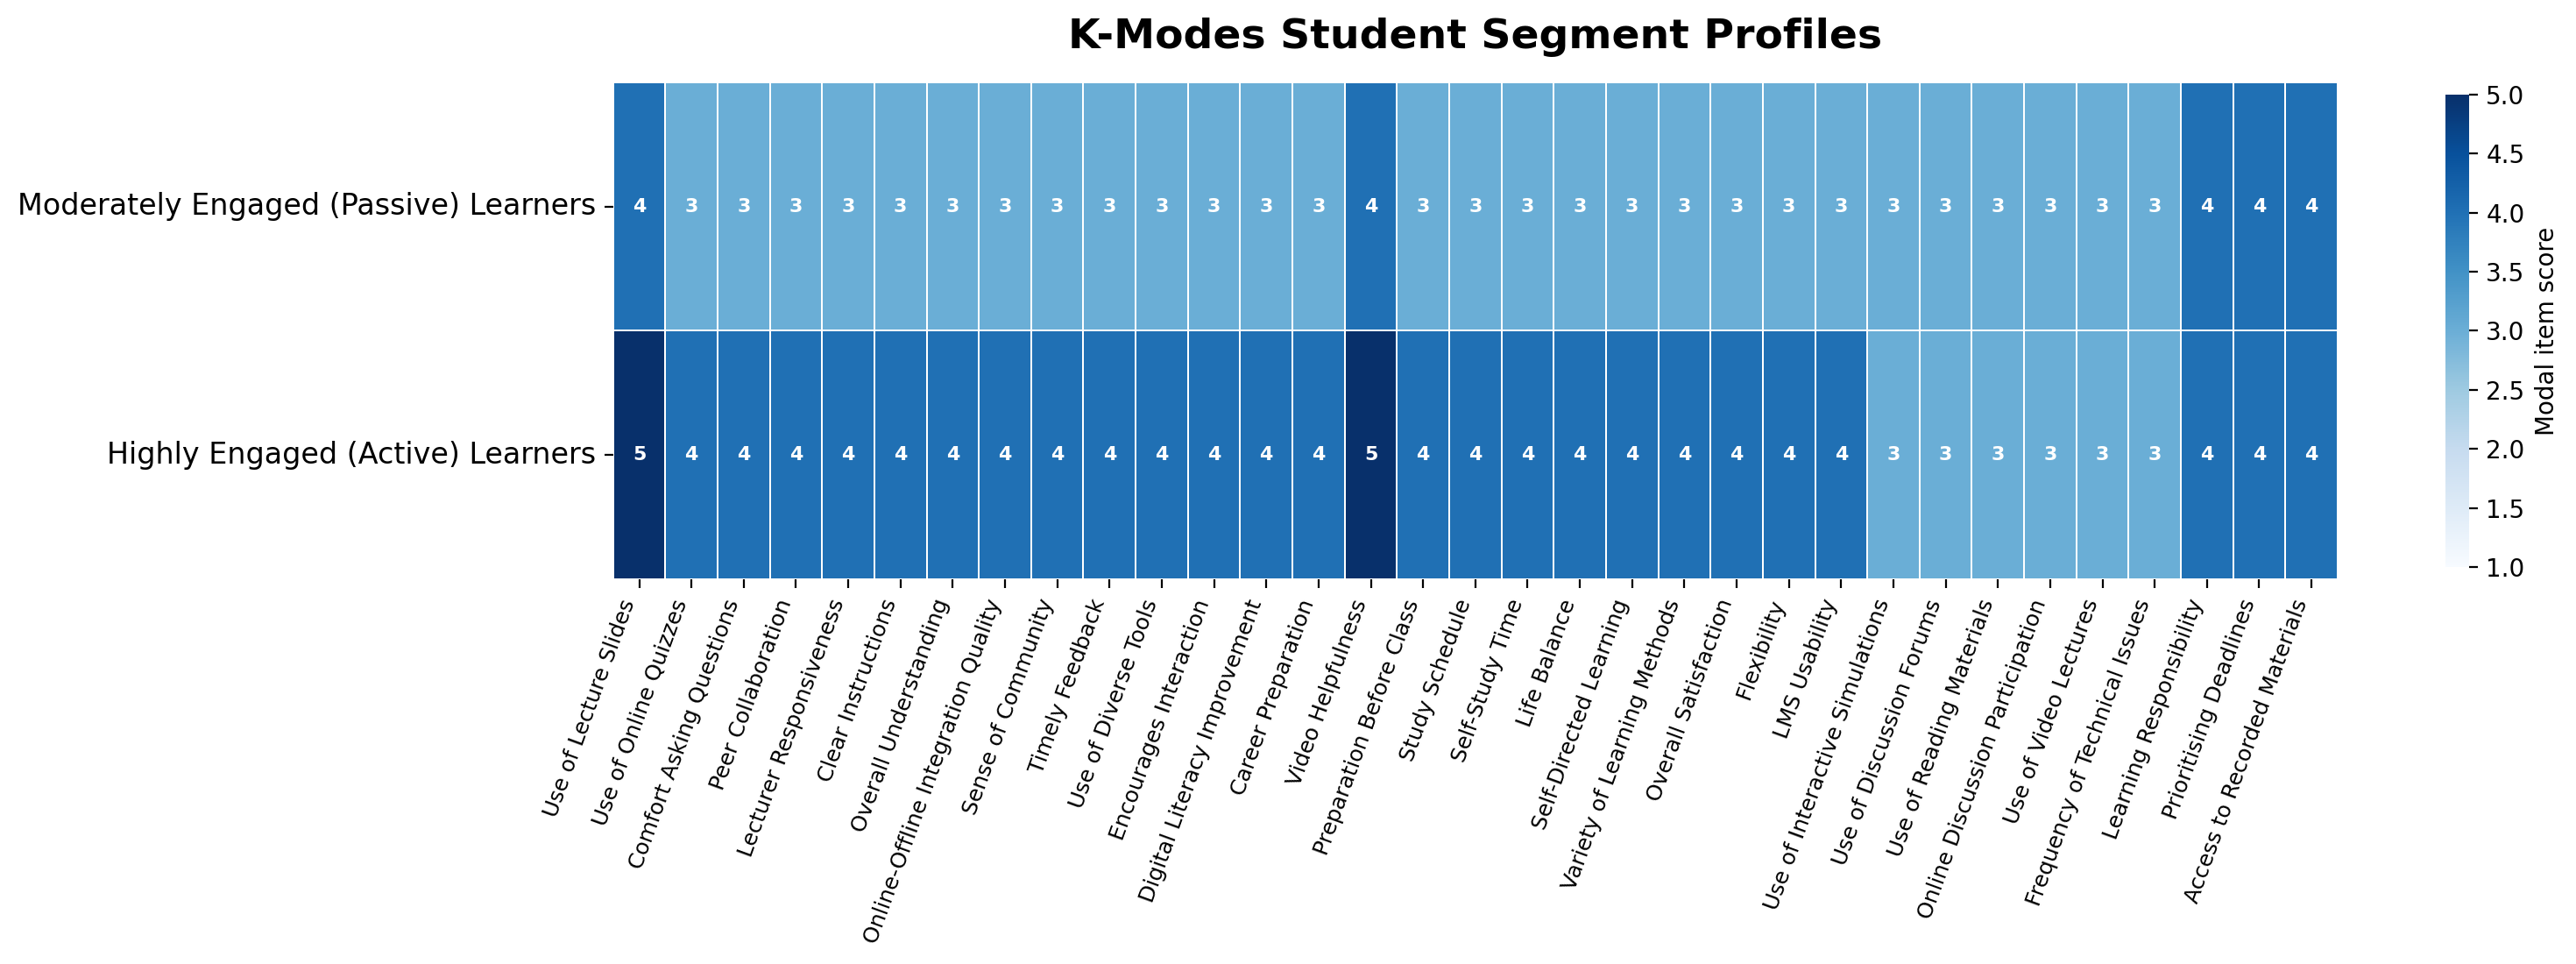

In [28]:
# Final segment labels
CLUSTER_LABEL_MAP = cluster_name_map.copy()

print("CLUSTER_LABEL_MAP:")
for k, v in CLUSTER_LABEL_MAP.items():
    print(f"  {k} -> {v}")

# Build profile table using MODE
km_profile = (
    df.assign(student_segment_label=lambda d: d['student_segment'].map(CLUSTER_LABEL_MAP))
      .groupby('student_segment_label')[cluster_vars]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Keep row order explicit
row_order = [
    'Moderately Engaged (Passive) Learners',
    'Highly Engaged (Active) Learners'
]
km_profile = km_profile.loc[row_order]

# Order variables by difference between clusters
if km_profile.shape[0] == 2:
    diff_order = (km_profile.iloc[0] - km_profile.iloc[1]).abs().sort_values(ascending=False).index
else:
    diff_order = km_profile.var(axis=0).sort_values(ascending=False).index

km_profile_plot = km_profile[diff_order].copy()

display_cols_ordered = [
    pretty_label.get(c, c.replace('_', ' ').title())
    for c in km_profile_plot.columns
]

# Plot main heatmap
plt.figure(figsize=(16, 5.6), dpi=200)

ax = sns.heatmap(
    km_profile_plot,
    cmap='Blues',
    vmin=1, vmax=5,
    annot=True,
    fmt='.0f',
    annot_kws={'size': 8, 'weight': 'bold'},
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': 'Modal item score', 'shrink': 0.95}
)

ax.set_title('K-Modes Student Segment Profiles', fontsize=17, weight='bold', pad=14)
ax.set_xlabel('')
ax.set_ylabel('')

ax.set_xticklabels(display_cols_ordered, rotation=70, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

In [29]:

cluster_name_map = {
    1: 'Moderately Engaged (Passive) Learners',
    2: 'Highly Engaged (Active) Learners'
}

# Use final descriptive labels directly
CLUSTER_LABEL_MAP = cluster_name_map.copy()

# Consistent plotting/display settings
CLUSTER_ORDER = [1, 2]

CLUSTER_PALETTE = {
    1: '#e74c3c',   # red
    2: '#2ecc71'    # green
}


# Keep final dataframe columns consistent with earlier sections
df['cluster_label'] = df['student_segment'].map(CLUSTER_LABEL_MAP)

print(f"K_KMODES          = {K_KMODES}")
print(f"CLUSTER_LABEL_MAP = {CLUSTER_LABEL_MAP}")
print(f"CLUSTER_ORDER     = {CLUSTER_ORDER}")
print()

print("Cluster distribution (K-Modes final model):")
print(
    df['cluster_label']
      .value_counts()
      .reindex([CLUSTER_LABEL_MAP[k] for k in CLUSTER_ORDER])
)

print()
print("Cluster proportions (%):")
print(
    df['cluster_label']
      .value_counts(normalize=True)
      .mul(100)
      .round(1)
      .reindex([CLUSTER_LABEL_MAP[k] for k in CLUSTER_ORDER])
)

K_KMODES          = 2
CLUSTER_LABEL_MAP = {1: 'Moderately Engaged (Passive) Learners', 2: 'Highly Engaged (Active) Learners'}
CLUSTER_ORDER     = [1, 2]

Cluster distribution (K-Modes final model):
cluster_label
Moderately Engaged (Passive) Learners    357
Highly Engaged (Active) Learners         231
Name: count, dtype: int64

Cluster proportions (%):
cluster_label
Moderately Engaged (Passive) Learners    60.7
Highly Engaged (Active) Learners         39.3
Name: proportion, dtype: float64


In [30]:
# ──  Cluster size visualisation 
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Labels
cluster_name_map = {
    1: 'Moderately Engaged (Passive) Learners',
    2: 'Highly Engaged (Active) Learners'
}

CLUSTER_ORDER = [1, 2]

CLUSTER_PALETTE = { 1: '#e74c3c', 2: '#2ecc71' }

# Summary
cluster_counts = (
    df['student_segment']
    .value_counts()
    .reindex(CLUSTER_ORDER)
    .fillna(0)
    .astype(int)
)

cluster_perc = (cluster_counts / cluster_counts.sum() * 100).round(1)

# X-axis labels
x_labels = [
    f"Cluster {k}<br>{cluster_name_map[k]}"
    for k in CLUSTER_ORDER
]

colors = [CLUSTER_PALETTE[k] for k in CLUSTER_ORDER]

#  Create figure FIRST
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'xy'}, {'type': 'domain'}]],
    column_widths=[0.64, 0.36],
    subplot_titles=('Cluster Sizes', 'Cluster Proportions'),
    horizontal_spacing=0.08
)

# ── Bar chart
fig.add_trace(
    go.Bar(
        x=x_labels,
        y=cluster_counts.values,
        marker=dict(
            color=colors,
            line=dict(color='rgba(40,40,40,0.9)', width=1.2)
        ),
        text=[str(n) for n in cluster_counts.values],
        textposition='outside',
        textfont=dict(size=13),
        customdata=cluster_perc.values,
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Students: %{y}<br>"
            "Percentage: %{customdata:.1f}%<extra></extra>"
        ),
        showlegend=False
    ),
    row=1, col=1
)

# ── Donut chart
fig.add_trace(
    go.Pie(
        labels=[f"Cluster {k}: {cluster_name_map[k]}" for k in CLUSTER_ORDER],
        values=cluster_counts.values,
        hole=0.60,
        marker=dict(colors=colors, line=dict(color='white', width=2)),
        textinfo='percent',
        textfont=dict(size=12),
        hovertemplate=(
            "<b>%{label}</b><br>"
            "Students: %{value}<br>"
            "Percentage: %{percent}<extra></extra>"
        ),
        showlegend=False,
        sort=False
    ),
    row=1, col=2
)

# ── Axes styling (NOW valid)
fig.update_yaxes(
    range=[0, cluster_counts.max() * 1.15],
    title_text='Number of students',
    showgrid=True,
    gridcolor='rgba(0,0,0,0.08)',
    zeroline=False,
    row=1, col=1
)

fig.update_xaxes(
    title_text='Cluster ID and profile',
    row=1, col=1
)

# ── Layout
fig.update_layout(
    title=dict(
        text='K-Modes Student Segment Distribution',
        x=0.5,
        xanchor='center',
        font=dict(size=22)
    ),
    template='plotly_white',
    width=1250,
    height=700,
    margin=dict(t=120, l=60, r=40, b=70),
    showlegend=False
)

# Bar width
fig.update_traces(width=0.6, selector=dict(type='bar'))

fig.show()

In [31]:
from pathlib import Path
import json
import joblib

# Create models folder
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Full cluster labels for app display
cluster_label_map = {
    1: "Cluster 1: Moderately Engaged (Passive) Learners",
    2: "Cluster 2: Highly Engaged (Active) Learners"
}

# Save trained K-Modes model
joblib.dump(km_final, MODEL_DIR / "kmodes_model.pkl")

# Save feature columns used during clustering
with open(MODEL_DIR / "kmodes_feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(cluster_vars, f, indent=2, ensure_ascii=False)

# Save cluster label mapping
with open(MODEL_DIR / "kmodes_cluster_label_map.json", "w", encoding="utf-8") as f:
    json.dump(cluster_label_map, f, indent=2, ensure_ascii=False)

# Save preprocessing information
preprocessing_info = {
    "description": "K-Modes input preprocessing",
    "steps": [
        "Select the same 33 clustering features",
        "Convert each feature to integer",
        "Convert each feature to string",
        "Pass the resulting array to kmodes_model.predict()",
        "Add +1 to prediction output because the saved K-Modes model returns zero-based labels"
    ],
    "n_features": len(cluster_vars),
    "model_input_type": "categorical strings",
    "k": K_KMODES,
    "random_state": 43
}

with open(MODEL_DIR / "kmodes_preprocessing_info.json", "w", encoding="utf-8") as f:
    json.dump(preprocessing_info, f, indent=2, ensure_ascii=False)

print("Saved K-Modes model and metadata.")
print(f"Model path: {MODEL_DIR / 'kmodes_model.pkl'}")
print(f"Number of clustering features: {len(cluster_vars)}")

Saved K-Modes model and metadata.
Model path: models\kmodes_model.pkl
Number of clustering features: 33


### 2.3 GMM

In [32]:
# ── GMM input preparation ────────────────────────────────────────────────────
# The same 33 Likert-type ordinal indicators are used for GMM.


X_gmm = df[cluster_vars].copy()

print('Input shape:', X_gmm.shape)
print('Total nulls :', X_gmm.isna().sum().sum())

if X_gmm.isna().sum().sum() > 0:
    raise ValueError('CLUSTER_VARS contains missing values. Clean or impute before GMM.')

# Force numeric representation
X_gmm = X_gmm.astype(float)

print('\nSample raw values:')
display(X_gmm.head())

# Standardize before GMM
scaler = StandardScaler()
X_gmm_fit = scaler.fit_transform(X_gmm)

print('\nScaled matrix shape:', X_gmm_fit.shape)
print('Scaled means (first 5):', np.round(X_gmm_fit.mean(axis=0)[:5], 3))
print('Scaled stds  (first 5):', np.round(X_gmm_fit.std(axis=0)[:5], 3))

Input shape: (588, 33)
Total nulls : 0

Sample raw values:


,use_lecture_slides,use_video_lectures,use_quizzes,use_articles,use_forums,use_simulations,online_discussion_participation,peer_collaboration,comfort_asking_questions,sense_of_community,...,digital_literacy_improvement,tech_issues_freq,lms_usability,overall_satisfaction,benefit_flexibility,benefit_variety,benefit_recorded_access,benefit_self_study_time,benefit_life_balance,benefit_self_directed
0,1.0,2.0,3.0,4.0,5.0,1.0,3.0,2.0,4.0,3.0,...,1.0,2.0,3.0,4.0,4.0,3.0,5.0,2.0,1.0,2.0
1,3.0,3.0,3.0,4.0,4.0,4.0,3.0,4.0,3.0,4.0,...,4.0,3.0,3.0,4.0,3.0,4.0,4.0,4.0,1.0,4.0
2,4.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,...,5.0,3.0,4.0,4.0,4.0,3.0,4.0,4.0,3.0,5.0
3,5.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,4.0,4.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0
4,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0



Scaled matrix shape: (588, 33)
Scaled means (first 5): [-0.  0. -0.  0.  0.]
Scaled stds  (first 5): [1. 1. 1. 1. 1.]


In [33]:
# ── GMM model search (BIC/AIC from K = 1..6) ────────────────────────────────
K_RANGE_GMM = range(1, 7)

gmm_results = []

for k in K_RANGE_GMM:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        n_init=10,
        random_state=42
    )
    gmm.fit(X_gmm_fit)

    gmm_results.append({
        'k': k,
        'bic': gmm.bic(X_gmm_fit),
        'aic': gmm.aic(X_gmm_fit)
    })

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.round(4))

,k,bic,aic
0,1,53185.1189,50585.3431
1,2,55099.8440,49895.9157
2,3,57545.7974,49737.7165
3,4,57556.4567,47144.2233
4,5,60516.5031,47500.1171
5,6,63518.1809,47897.6424


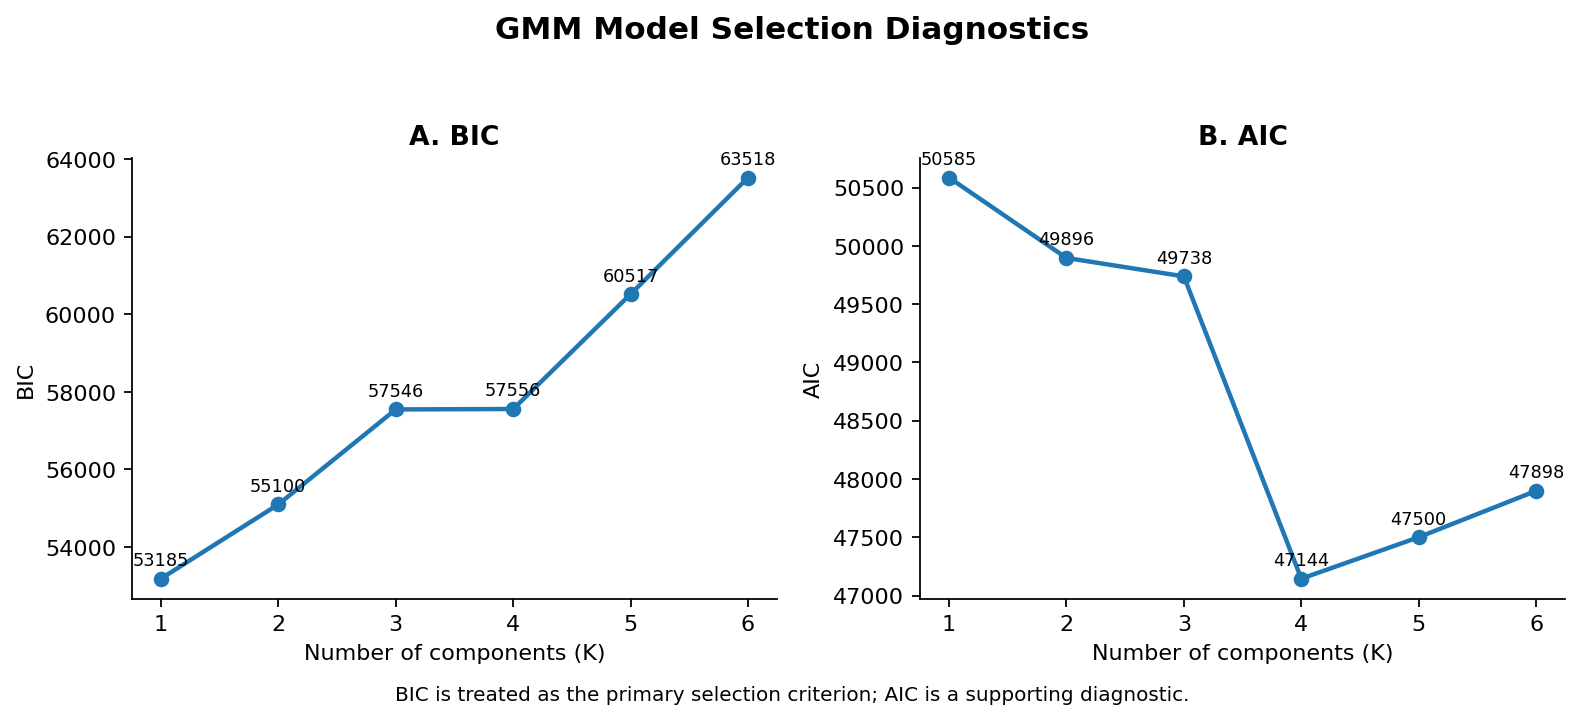

In [34]:
# ── GMM model-selection plots (2 panels) ─────────────────────────────────────
from matplotlib.ticker import FormatStrFormatter

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=160)
fig.patch.set_facecolor('white')

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis='both', labelsize=10)

def annotate_points(ax, x, y, fmt='{:.1f}'):
    for xi, yi in zip(x, y):
        if pd.notna(yi):
            ax.annotate(fmt.format(yi), (xi, yi),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', fontsize=8)

# A. BIC
ax = axes[0]
ax.plot(gmm_results_df['k'], gmm_results_df['bic'], marker='o', linewidth=2)
style_ax(ax)
ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax.set_xticks(gmm_results_df['k'])
annotate_points(ax, gmm_results_df['k'], gmm_results_df['bic'], '{:.0f}')
ax.set_title('A. BIC', fontsize=12, weight='bold')
ax.set_xlabel('Number of components (K)', fontsize=10)
ax.set_ylabel('BIC', fontsize=10)

# B. AIC
ax = axes[1]
ax.plot(gmm_results_df['k'], gmm_results_df['aic'], marker='o', linewidth=2)
style_ax(ax)
ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax.set_xticks(gmm_results_df['k'])
annotate_points(ax, gmm_results_df['k'], gmm_results_df['aic'], '{:.0f}')
ax.set_title('B. AIC', fontsize=12, weight='bold')
ax.set_xlabel('Number of components (K)', fontsize=10)
ax.set_ylabel('AIC', fontsize=10)

fig.suptitle('GMM Model Selection Diagnostics', fontsize=14, weight='bold', y=1.05)
fig.text(
    0.5, -0.02,
    'BIC is treated as the primary selection criterion; AIC is a supporting diagnostic.',
    ha='center', fontsize=9
)

plt.tight_layout()
plt.show()

GMM model selection was first evaluated for K = 1 to 6 using BIC and AIC. BIC favored K = 1, indicating weak evidence for Gaussian-separated latent clusters. A K = 2 GMM was then fitted only as a comparison model alongside the two-cluster K-Modes solution.

K = 1, then:

GMM does not strongly support cluster structure in Gaussian terms
this means the data may not naturally separate under GMM assumptions

multi-component GMM comparison

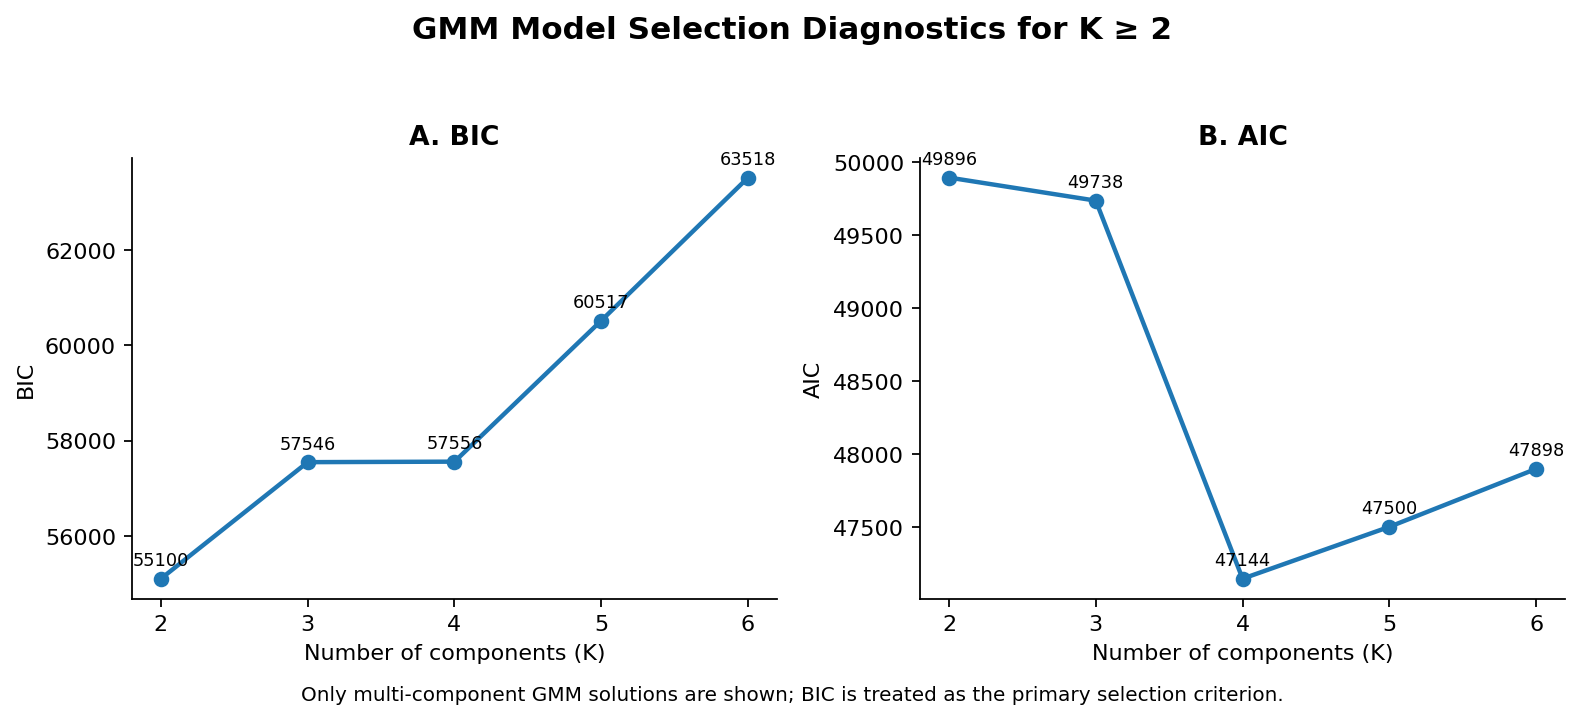

In [35]:
# ── GMM model-selection plots from K = 2 onward ─────────────────────────────
from matplotlib.ticker import FormatStrFormatter

# Keep only K >= 2 for plotting
plot_df = gmm_results_df[gmm_results_df['k'] >= 2].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=160)
fig.patch.set_facecolor('white')

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis='both', labelsize=10)

def annotate_points(ax, x, y, fmt='{:.1f}'):
    for xi, yi in zip(x, y):
        if pd.notna(yi):
            ax.annotate(
                fmt.format(yi),
                (xi, yi),
                textcoords='offset points',
                xytext=(0, 6),
                ha='center',
                fontsize=8
            )

# A. BIC
ax = axes[0]
ax.plot(plot_df['k'], plot_df['bic'], marker='o', linewidth=2)
style_ax(ax)
ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax.set_xticks(plot_df['k'])
annotate_points(ax, plot_df['k'], plot_df['bic'], '{:.0f}')
ax.set_title('A. BIC', fontsize=12, weight='bold')
ax.set_xlabel('Number of components (K)', fontsize=10)
ax.set_ylabel('BIC', fontsize=10)

# B. AIC
ax = axes[1]
ax.plot(plot_df['k'], plot_df['aic'], marker='o', linewidth=2)
style_ax(ax)
ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax.set_xticks(plot_df['k'])
annotate_points(ax, plot_df['k'], plot_df['aic'], '{:.0f}')
ax.set_title('B. AIC', fontsize=12, weight='bold')
ax.set_xlabel('Number of components (K)', fontsize=10)
ax.set_ylabel('AIC', fontsize=10)

fig.suptitle('GMM Model Selection Diagnostics for K ≥ 2', fontsize=14, weight='bold', y=1.05)
fig.text(
    0.5, -0.02,
    'Only multi-component GMM solutions are shown; BIC is treated as the primary selection criterion.',
    ha='center',
    fontsize=9
)

plt.tight_layout()
plt.show()

In [36]:
# ── Fit pragmatic final GMM solution 
K_GMM = 2

gmm_final = GaussianMixture(
    n_components=K_GMM,
    covariance_type='full',
    n_init=10,
    random_state=42
)
gmm_final.fit(X_gmm_fit)

# Shift labels to start from 1 instead of 0
gmm_labels = gmm_final.predict(X_gmm_fit) + 1
gmm_probs = gmm_final.predict_proba(X_gmm_fit)

df_gmm = df.copy()
df_gmm['cluster_gmm'] = gmm_labels
df_gmm['gmm_confidence'] = gmm_probs.max(axis=1)

print(df_gmm['cluster_gmm'].value_counts().sort_index())
print(df_gmm['gmm_confidence'].describe())

cluster_gmm
1    144
2    444
Name: count, dtype: int64
count    588.000000
mean       0.992611
std        0.031542
min        0.606453
25%        0.998231
50%        0.999858
75%        0.999995
max        1.000000
Name: gmm_confidence, dtype: float64


In [37]:
# ── GMM profile on clustering items ──────────────────────────────────────────
gmm_profile = (
    df_gmm.groupby('cluster_gmm')[cluster_vars]
    .mean()
    .round(2)
)

display(gmm_profile)

,use_lecture_slides,use_video_lectures,use_quizzes,use_articles,use_forums,use_simulations,online_discussion_participation,peer_collaboration,comfort_asking_questions,sense_of_community,...,digital_literacy_improvement,tech_issues_freq,lms_usability,overall_satisfaction,benefit_flexibility,benefit_variety,benefit_recorded_access,benefit_self_study_time,benefit_life_balance,benefit_self_directed
cluster_gmm,,,,,,,,,,,,,,,,,,,,,
1,4.05,2.98,3.49,3.05,2.70,2.41,2.46,3.15,3.18,2.95,...,2.92,3.42,3.08,3.11,3.42,3.33,3.82,3.71,3.38,3.53
2,4.11,3.42,3.68,3.07,3.09,2.94,3.03,3.41,3.46,3.30,...,3.55,3.29,3.53,3.61,3.78,3.71,3.96,4.02,3.76,3.88


### 3.4  Stability Analysis — 30 Seeds at K_BEST

Pairwise NMI across 30 independent random-seed runs. NMI is invariant to label permutation — it measures whether different random starts converge to the same partition structure, not whether they produce the same label numbers.

**Threshold:** NMI ≥ 0.8 = stable. NMI < 0.8 = sensitive to initialisation.

In [38]:
import time
from sklearn.metrics import normalized_mutual_info_score

# ── 6.4 Stability analysis across 30 seeds ───────────────────────────────────
N_RUNS = 30
SEEDS = [RANDOM_STATE + i * 7 for i in range(N_RUNS)]

# Final model settings
K_BEST = 2
GMM_COV_TYPE = 'full'

gmm_lbl_list = []
km_lbl_list = []

print(f"Running {N_RUNS} seed runs at K={K_BEST} ...")
t0 = time.time()

for seed in SEEDS:
    # GMM comparison model
    gmm = GaussianMixture(
        n_components=K_BEST,
        covariance_type=GMM_COV_TYPE,
        n_init=3,
        max_iter=500,
        random_state=seed
    )
    gmm.fit(X_gmm_fit)
    gmm_lbl_list.append(gmm.predict(X_gmm_fit))

    # K-Modes main segmentation model
    km = KModes(
        n_clusters=K_BEST,
        init='Huang',
        n_init=5,
        random_state=seed,
        verbose=0
    )
    km_lbl_list.append(km.fit_predict(X_km_fit))

def pairwise_nmi(label_list):
    scores = [
        normalized_mutual_info_score(label_list[i], label_list[j])
        for i in range(len(label_list))
        for j in range(i + 1, len(label_list))
    ]
    return float(np.mean(scores)), float(np.std(scores))

GMM_NMI, gmm_nmi_std = pairwise_nmi(gmm_lbl_list)
KM_NMI, km_nmi_std = pairwise_nmi(km_lbl_list)

print(f"Done in {time.time() - t0:.1f}s\n")
print("=" * 56)
print(f"  STABILITY — PAIRWISE NMI (K={K_BEST}, {N_RUNS} seeds)")
print("=" * 56)
print(f"  K-Modes (main)      : {KM_NMI:.4f} ± {km_nmi_std:.4f}")
print(f"  GMM (comparison)    : {GMM_NMI:.4f} ± {gmm_nmi_std:.4f}")
print("\n  NMI >= 0.80 = stable | NMI < 0.80 = sensitive to initialization")

Running 30 seed runs at K=2 ...
Done in 42.0s

  STABILITY — PAIRWISE NMI (K=2, 30 seeds)
  K-Modes (main)      : 0.8987 ± 0.0951
  GMM (comparison)    : 0.8026 ± 0.1257

  NMI >= 0.80 = stable | NMI < 0.80 = sensitive to initialization


### Stability note:
Across 30 random seeds at K=2, 
GMM is more stable but less balanced and BIC favors K=1.

####. GMM

**Why GMM for 33 Likert ordinals?**
All clustering inputs are numeric ordinals on the same 1–5 scale after StandardScaling. GMM is the natural choice because:
- It operates directly in the numeric ordinal space with no information loss
- Soft membership probabilities identify genuinely borderline students — students near   cluster boundaries receive a high entropy score rather than an arbitrary hard assignment



In [39]:
# ── 7.1 GMM comparison fit (soft-clustering reference) ───────────────────────
gmm = GaussianMixture(
    n_components=K_BEST,
    covariance_type=GMM_COV_TYPE,
    n_init=10,
    max_iter=500,
    random_state=RANDOM_STATE,
)
gmm.fit(X_gmm_fit)

gmm_proba = gmm.predict_proba(X_gmm_fit)                       # (n, K_BEST)
gmm_labels = gmm.predict(X_gmm_fit) + 1                       # 1-indexed IDs
gmm_entropy = -np.sum(gmm_proba * np.log(gmm_proba + 1e-12), axis=1)
max_prob = gmm_proba.max(axis=1)

print(f"GMM comparison model  K={K_BEST}  cov={GMM_COV_TYPE}  converged={gmm.converged_}")
print(f"  BIC              : {gmm.bic(X_gmm_fit):.2f}")
print(f"  AIC              : {gmm.aic(X_gmm_fit):.2f}")
print(f"  Log-likelihood   : {gmm.lower_bound_:.4f}")
print(f"  Mean entropy     : {gmm_entropy.mean():.4f}  (lower = more confident)")
print(f"  p >= 0.90 (high) : {(max_prob >= 0.9).sum()} "
      f"({(max_prob >= 0.9).mean()*100:.1f}%)")
print(f"  p < 0.60 (ambig) : {(max_prob < 0.6).sum()} "
      f"({(max_prob < 0.6).mean()*100:.1f}%)")
print()
print("Cluster distribution (comparison labels):")
for cid in sorted(np.unique(gmm_labels)):
    n = (gmm_labels == cid).sum()
    print(f"  Cluster {cid}: {n} students ({n/len(gmm_labels)*100:.1f}%)")

# Store comparison outputs on df
df.loc[idx, 'gmm_cluster_id'] = gmm_labels
df.loc[idx, 'gmm_entropy'] = gmm_entropy

for k in range(K_BEST):
    df.loc[idx, f'gmm_prob_c{k+1}'] = gmm_proba[:, k]

GMM comparison model  K=2  cov=full  converged=True
  BIC              : 55099.84
  AIC              : 49895.92
  Log-likelihood   : -40.4065
  Mean entropy     : 0.0263  (lower = more confident)
  p >= 0.90 (high) : 578 (98.3%)
  p < 0.60 (ambig) : 0 (0.0%)

Cluster distribution (comparison labels):
  Cluster 1: 144 students (24.5%)
  Cluster 2: 444 students (75.5%)


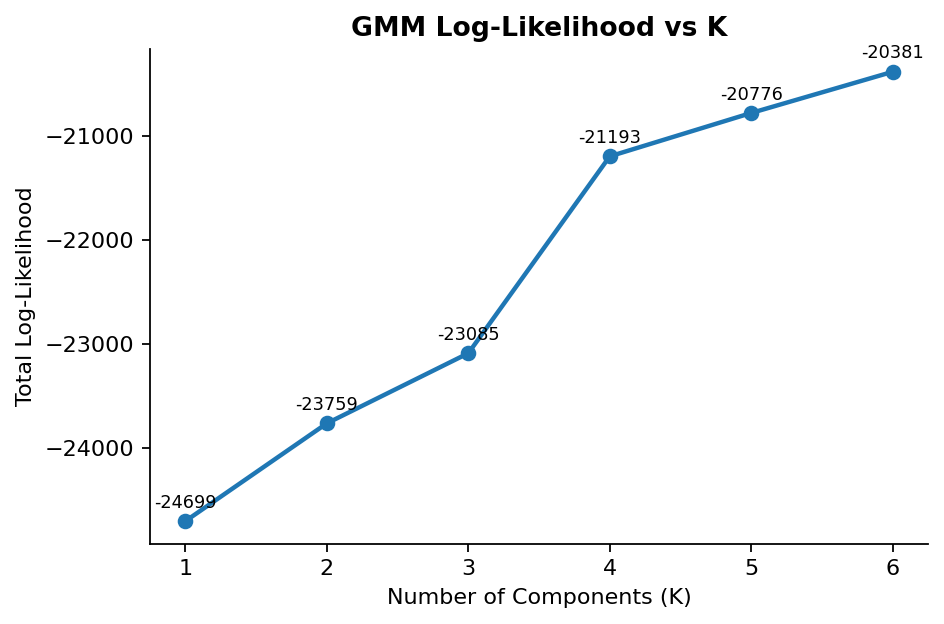

In [40]:
# ── GMM Log-Likelihood vs K ────────────────────────────────────────────────
results = []

for k in range(1, 7):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=GMM_COV_TYPE,   # keep consistent with main model
        n_init=10,
        max_iter=500,
        random_state=RANDOM_STATE
    )
    gmm.fit(X_gmm_fit)

    total_ll = gmm.lower_bound_ * X_gmm_fit.shape[0]

    results.append({
        "k": k,
        "log_likelihood": total_ll,
        "bic": gmm.bic(X_gmm_fit),
        "aic": gmm.aic(X_gmm_fit)
    })

df_ll = pd.DataFrame(results)

# ── Plot ───────────────────────────────────────────────────────────────────
from matplotlib.ticker import FormatStrFormatter

fig, ax = plt.subplots(figsize=(6, 4), dpi=160)

# Style (same as your other plots)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.tick_params(axis='both', labelsize=10)

# Line plot
ax.plot(df_ll["k"], df_ll["log_likelihood"], marker='o', linewidth=2)

# Format
ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax.set_xticks(df_ll["k"])

# Annotate
for x, y in zip(df_ll["k"], df_ll["log_likelihood"]):
    ax.annotate(f"{y:.0f}", (x, y),
                textcoords='offset points', xytext=(0, 6),
                ha='center', fontsize=8)

ax.set_title("GMM Log-Likelihood vs K", fontsize=12, weight='bold')
ax.set_xlabel("Number of Components (K)", fontsize=10)
ax.set_ylabel("Total Log-Likelihood", fontsize=10)

plt.tight_layout()
plt.show()

Key conclusion about the “jump at K=4”



In [41]:
from sklearn.mixture import GaussianMixture

gmm_k4 = GaussianMixture(
    n_components=4,
    covariance_type="full",
    n_init=10,
    random_state=42
)

gmm_k4.fit(X_gmm_fit)
gmm_labels_k4 = gmm_k4.predict(X_gmm_fit) + 1


from collections import Counter
Counter(gmm_labels_k4)

Counter({np.int64(4): 339, np.int64(2): 147, np.int64(3): 82, np.int64(1): 20})

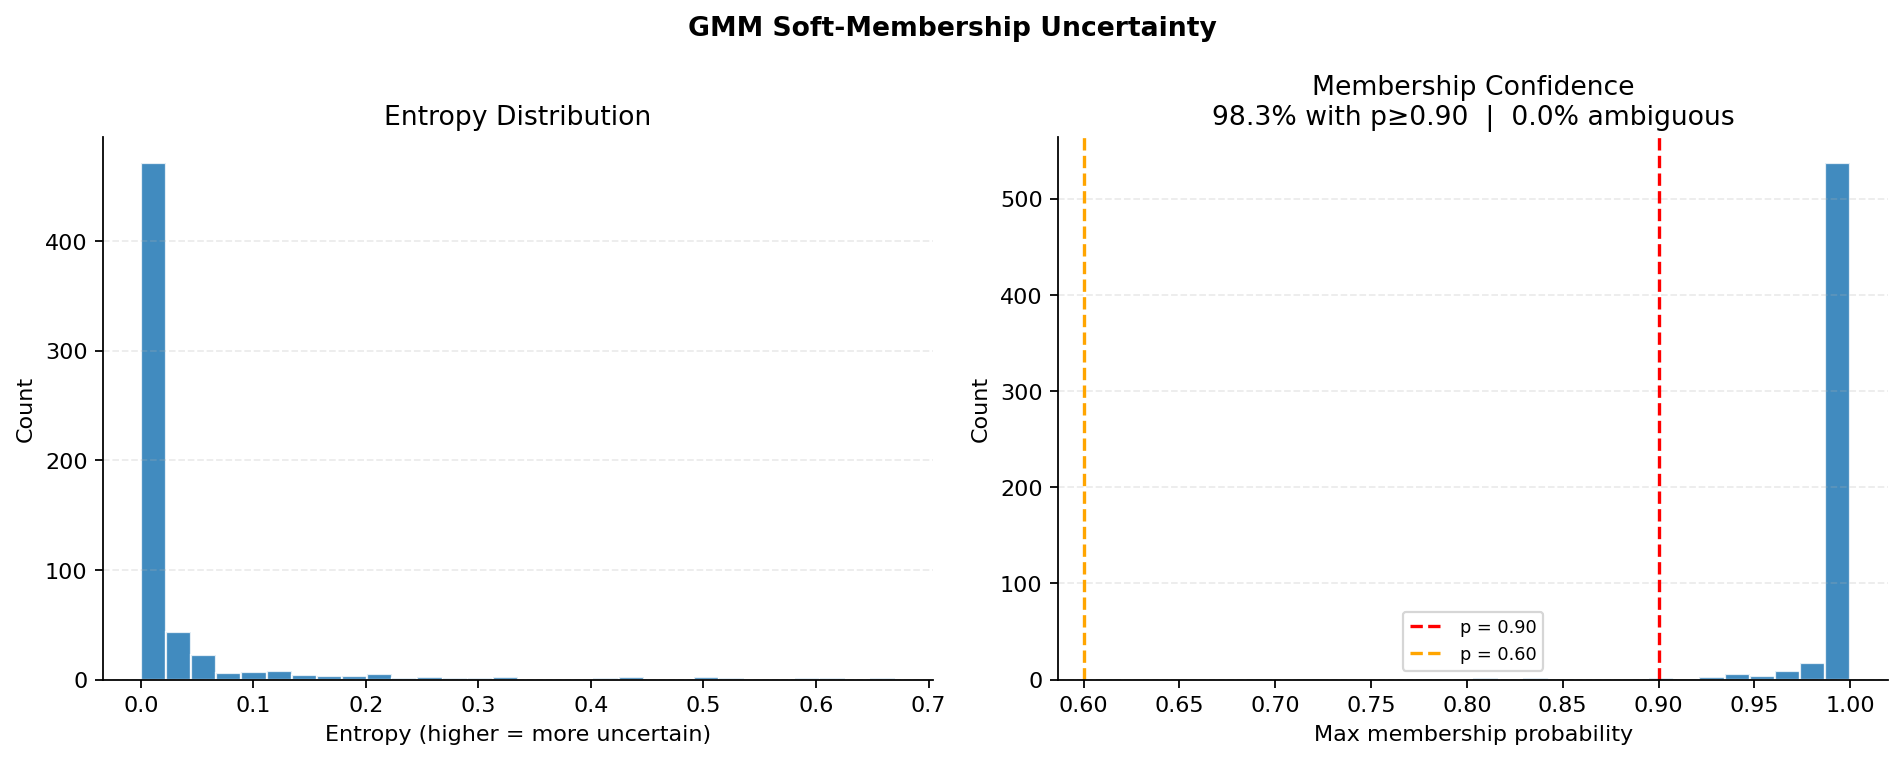

In [42]:
# ──  GMM soft-membership visualisation ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8), dpi=160)
fig.suptitle('GMM Soft-Membership Uncertainty', fontsize=12, fontweight='bold')

ax1.hist(gmm_entropy, bins=30, edgecolor='white', alpha=0.85)
ax1.set_title('Entropy Distribution')
ax1.set_xlabel('Entropy (higher = more uncertain)')
ax1.set_ylabel('Count')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, axis='y', alpha=0.25, linestyle='--')

ax2.hist(max_prob, bins=30, edgecolor='white', alpha=0.85)
ax2.axvline(0.9, color='red', linestyle='--', linewidth=1.5, label='p = 0.90')
ax2.axvline(0.6, color='orange', linestyle='--', linewidth=1.5, label='p = 0.60')
ax2.set_title(
    f'Membership Confidence\n'
    f'{(max_prob >= 0.9).mean()*100:.1f}% with p≥0.90  |  '
    f'{(max_prob < 0.6).mean()*100:.1f}% ambiguous'
)
ax2.set_xlabel('Max membership probability')
ax2.set_ylabel('Count')
ax2.legend(fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, axis='y', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

#### 7. Comparison & Validation

In [43]:
# ── 9.1 Shared comparison helper ─────────────────────────────────────────────
def balance_cv(labels):
    _, counts = np.unique(labels, return_counts=True)
    return float(counts.std() / counts.mean()) if counts.mean() > 0 else np.inf

def cluster_size_summary(labels):
    _, counts = np.unique(labels, return_counts=True)
    return int(counts.min()), int(counts.max())

In [44]:
# ── 9.2 Shared comparison table ──────────────────────────────────────────────
km_min, km_max = cluster_size_summary(km_labels)
gmm_min, gmm_max = cluster_size_summary(gmm_labels)

shared_df = pd.DataFrame([
    {
        'Model': 'K-Modes (main)',
        'Stability NMI': round(KM_NMI, 4),
        'Balance CV': round(balance_cv(km_labels), 4),
        'Min cluster size': km_min,
        'Max cluster size': km_max
    },
    {
        'Model': 'GMM (comparison)',
        'Stability NMI': round(GMM_NMI, 4),
        'Balance CV': round(balance_cv(gmm_labels), 4),
        'Min cluster size': gmm_min,
        'Max cluster size': gmm_max
    }
]).set_index('Model')

print("=" * 68)
print(f"  SHARED MODEL COMPARISON TABLE (K={K_BEST})")
print("=" * 68)
print(shared_df.to_string())

  SHARED MODEL COMPARISON TABLE (K=2)
                  Stability NMI  Balance CV  Min cluster size  Max cluster size
Model                                                                          
K-Modes (main)           0.8987      0.2143               231               357
GMM (comparison)         0.8026      0.5102               144               444


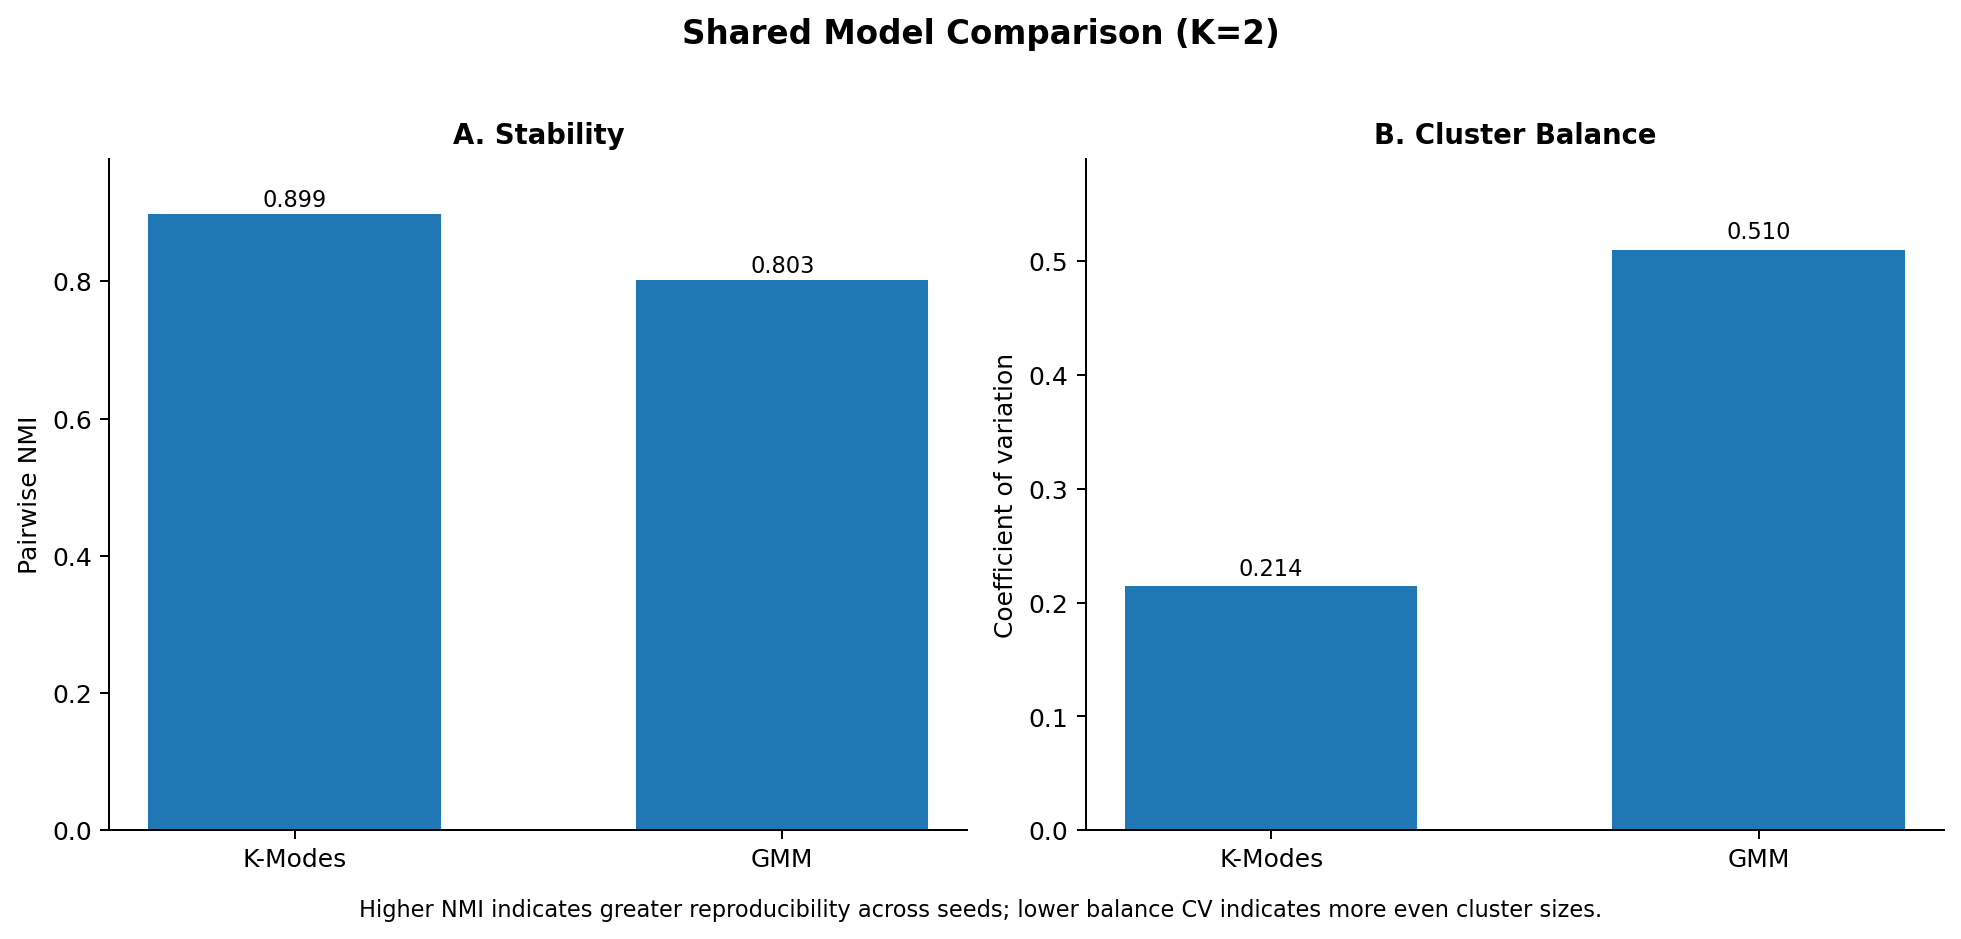

In [45]:
# ── 9.3 Shared comparison visualisation (thesis-clean) ──────────────────────
plot_df = shared_df.copy()
plot_df.index = ['K-Modes', 'GMM']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), dpi=180)
fig.suptitle(f'Shared Model Comparison (K={K_BEST})', fontsize=13, fontweight='bold', y=1.02)

# A. Stability NMI
ax = axes[0]
bars = ax.bar(plot_df.index, plot_df['Stability NMI'], width=0.6)
ax.set_title('A. Stability', fontsize=11, fontweight='bold')
ax.set_ylabel('Pairwise NMI', fontsize=10)
ax.set_ylim(0, max(plot_df['Stability NMI']) + 0.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

for bar, v in zip(bars, plot_df['Stability NMI']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
            ha='center', fontsize=9)

# B. Balance CV
ax = axes[1]
bars = ax.bar(plot_df.index, plot_df['Balance CV'], width=0.6)
ax.set_title('B. Cluster Balance', fontsize=11, fontweight='bold')
ax.set_ylabel('Coefficient of variation', fontsize=10)
ax.set_ylim(0, max(plot_df['Balance CV']) + 0.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

for bar, v in zip(bars, plot_df['Balance CV']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
            ha='center', fontsize=9)

fig.text(
    0.5, -0.02,
    'Higher NMI indicates greater reproducibility across seeds; lower balance CV indicates more even cluster sizes.',
    ha='center', fontsize=9
)

plt.tight_layout()
plt.show()

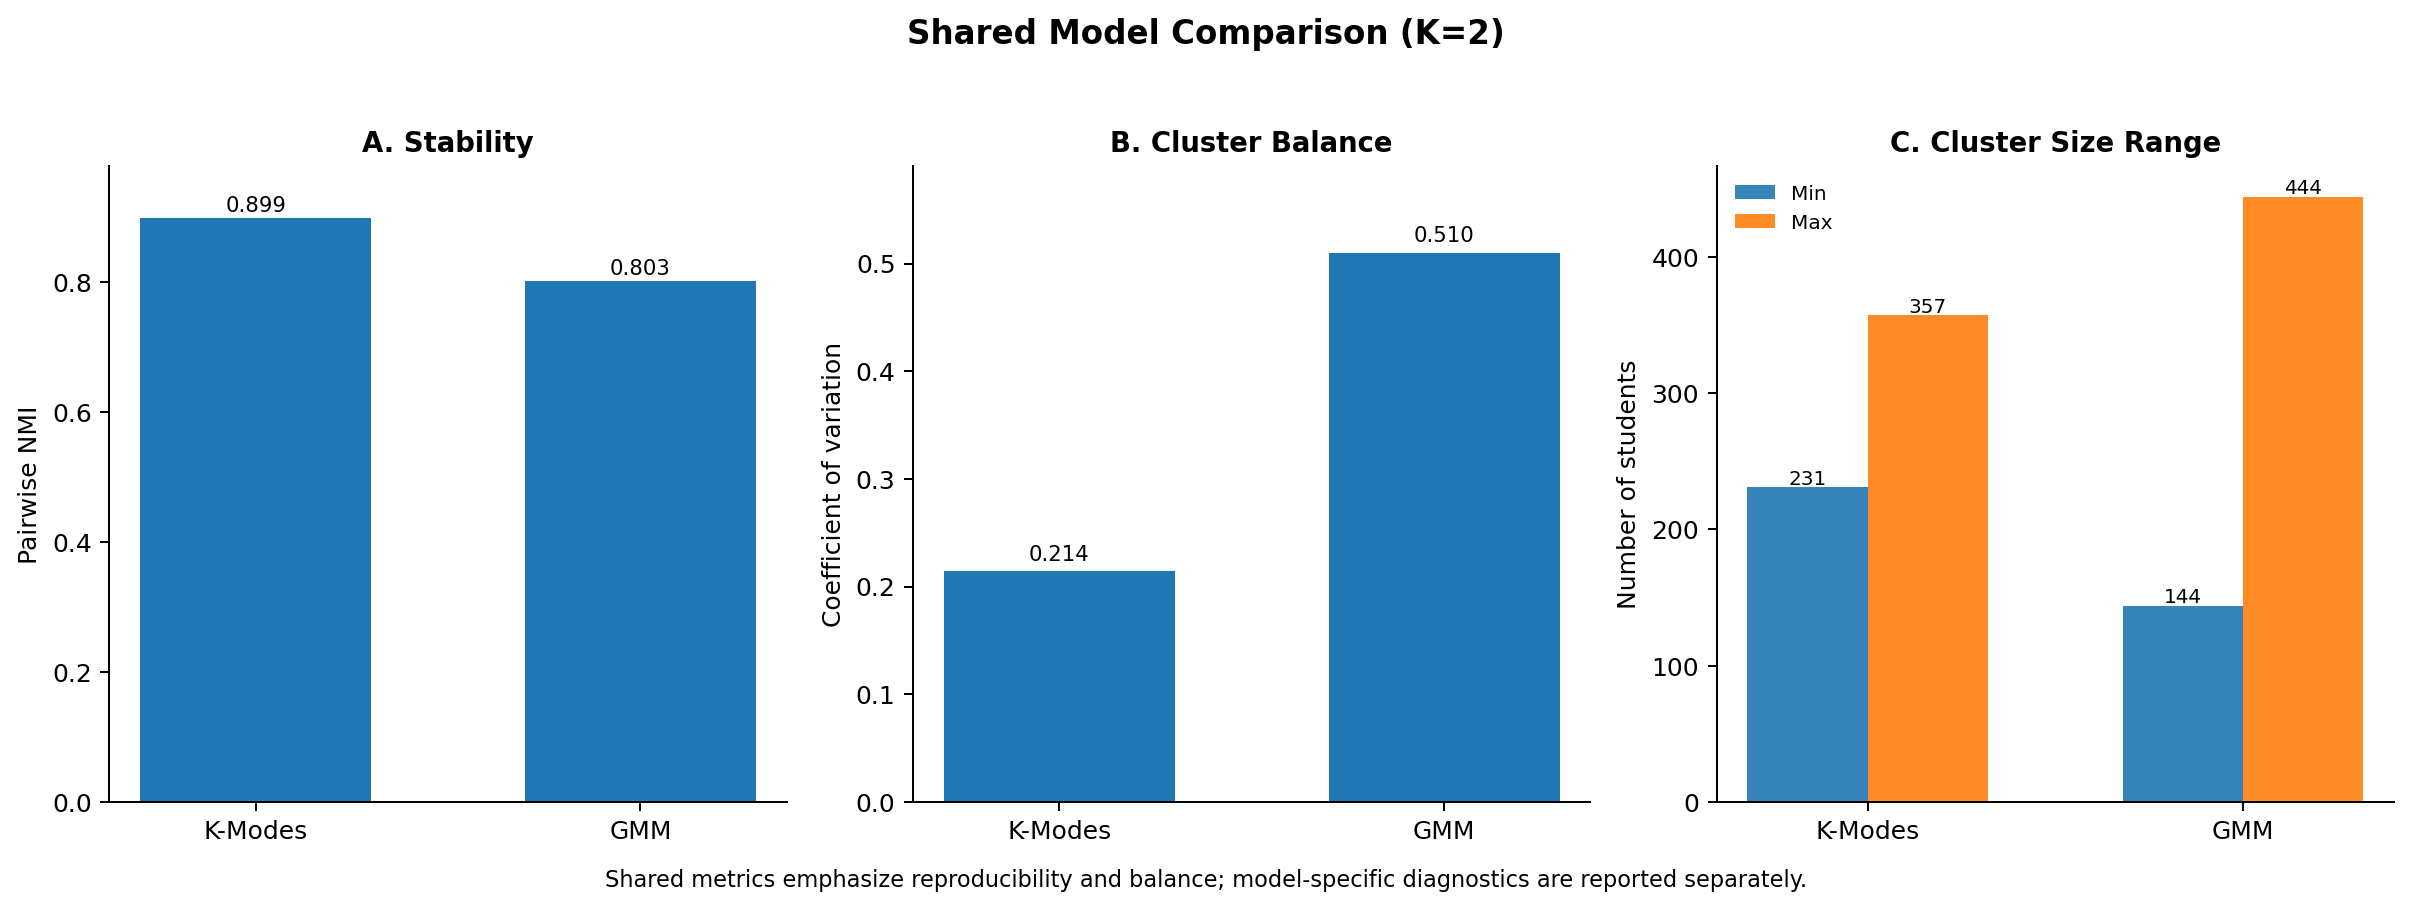

In [46]:
# ──  Shared comparison visualisation (improved 3-panel version) ──────────
plot_df = shared_df.copy()
plot_df.index = ['K-Modes', 'GMM']

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), dpi=180)
fig.suptitle(f'Shared Model Comparison (K={K_BEST})', fontsize=13, fontweight='bold', y=1.03)

# A. Stability
ax = axes[0]
bars = ax.bar(plot_df.index, plot_df['Stability NMI'], width=0.6)
ax.set_title('A. Stability', fontsize=11, fontweight='bold')
ax.set_ylabel('Pairwise NMI', fontsize=10)
ax.set_ylim(0, max(plot_df['Stability NMI']) + 0.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
for bar, v in zip(bars, plot_df['Stability NMI']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
            ha='center', fontsize=8.5)

# B. Balance
ax = axes[1]
bars = ax.bar(plot_df.index, plot_df['Balance CV'], width=0.6)
ax.set_title('B. Cluster Balance', fontsize=11, fontweight='bold')
ax.set_ylabel('Coefficient of variation', fontsize=10)
ax.set_ylim(0, max(plot_df['Balance CV']) + 0.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
for bar, v in zip(bars, plot_df['Balance CV']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
            ha='center', fontsize=8.5)

# C. Size range
ax = axes[2]
x = np.arange(len(plot_df.index))
mins = plot_df['Min cluster size'].values
maxs = plot_df['Max cluster size'].values

bars1 = ax.bar(x - 0.16, mins, width=0.32, label='Min', alpha=0.9)
bars2 = ax.bar(x + 0.16, maxs, width=0.32, label='Max', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_title('C. Cluster Size Range', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of students', fontsize=10)
ax.legend(frameon=False, fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

for bar, v in zip(bars1, mins):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v}', ha='center', fontsize=8)
for bar, v in zip(bars2, maxs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v}', ha='center', fontsize=8)

fig.text(
    0.5, -0.02,
    'Shared metrics emphasize reproducibility and balance; model-specific diagnostics are reported separately.',
    ha='center', fontsize=9
)

plt.tight_layout()
plt.show()

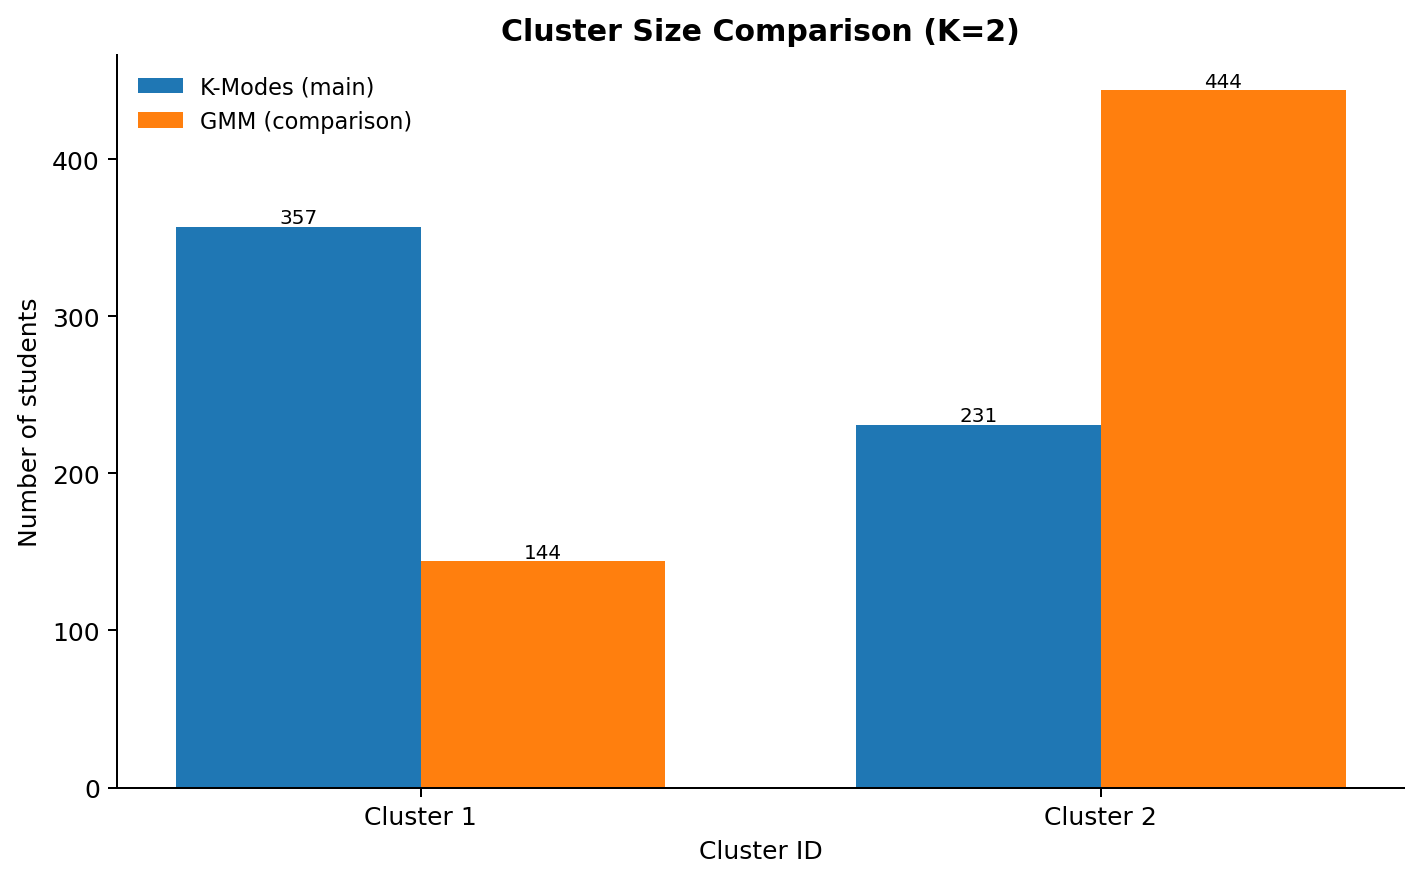

In [47]:
# ──  Side-by-side cluster size comparison ─────────────────────────────────
km_counts = pd.Series(km_labels).value_counts().sort_index()
gmm_counts = pd.Series(gmm_labels).value_counts().sort_index()

cluster_ids = sorted(set(km_counts.index).union(set(gmm_counts.index)))
km_vals = [km_counts.get(cid, 0) for cid in cluster_ids]
gmm_vals = [gmm_counts.get(cid, 0) for cid in cluster_ids]

x = np.arange(len(cluster_ids))
w = 0.36

fig, ax = plt.subplots(figsize=(8, 5), dpi=180)

bars1 = ax.bar(x - w/2, km_vals, width=w, label='K-Modes (main)')
bars2 = ax.bar(x + w/2, gmm_vals, width=w, label='GMM (comparison)')

ax.set_title(f'Cluster Size Comparison (K={K_BEST})', fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster ID', fontsize=10)
ax.set_ylabel('Number of students', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {cid}' for cid in cluster_ids])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.legend(frameon=False, fontsize=9)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 2, f'{int(h)}',
            ha='center', fontsize=8)

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 2, f'{int(h)}',
            ha='center', fontsize=8)

plt.tight_layout()
plt.show()

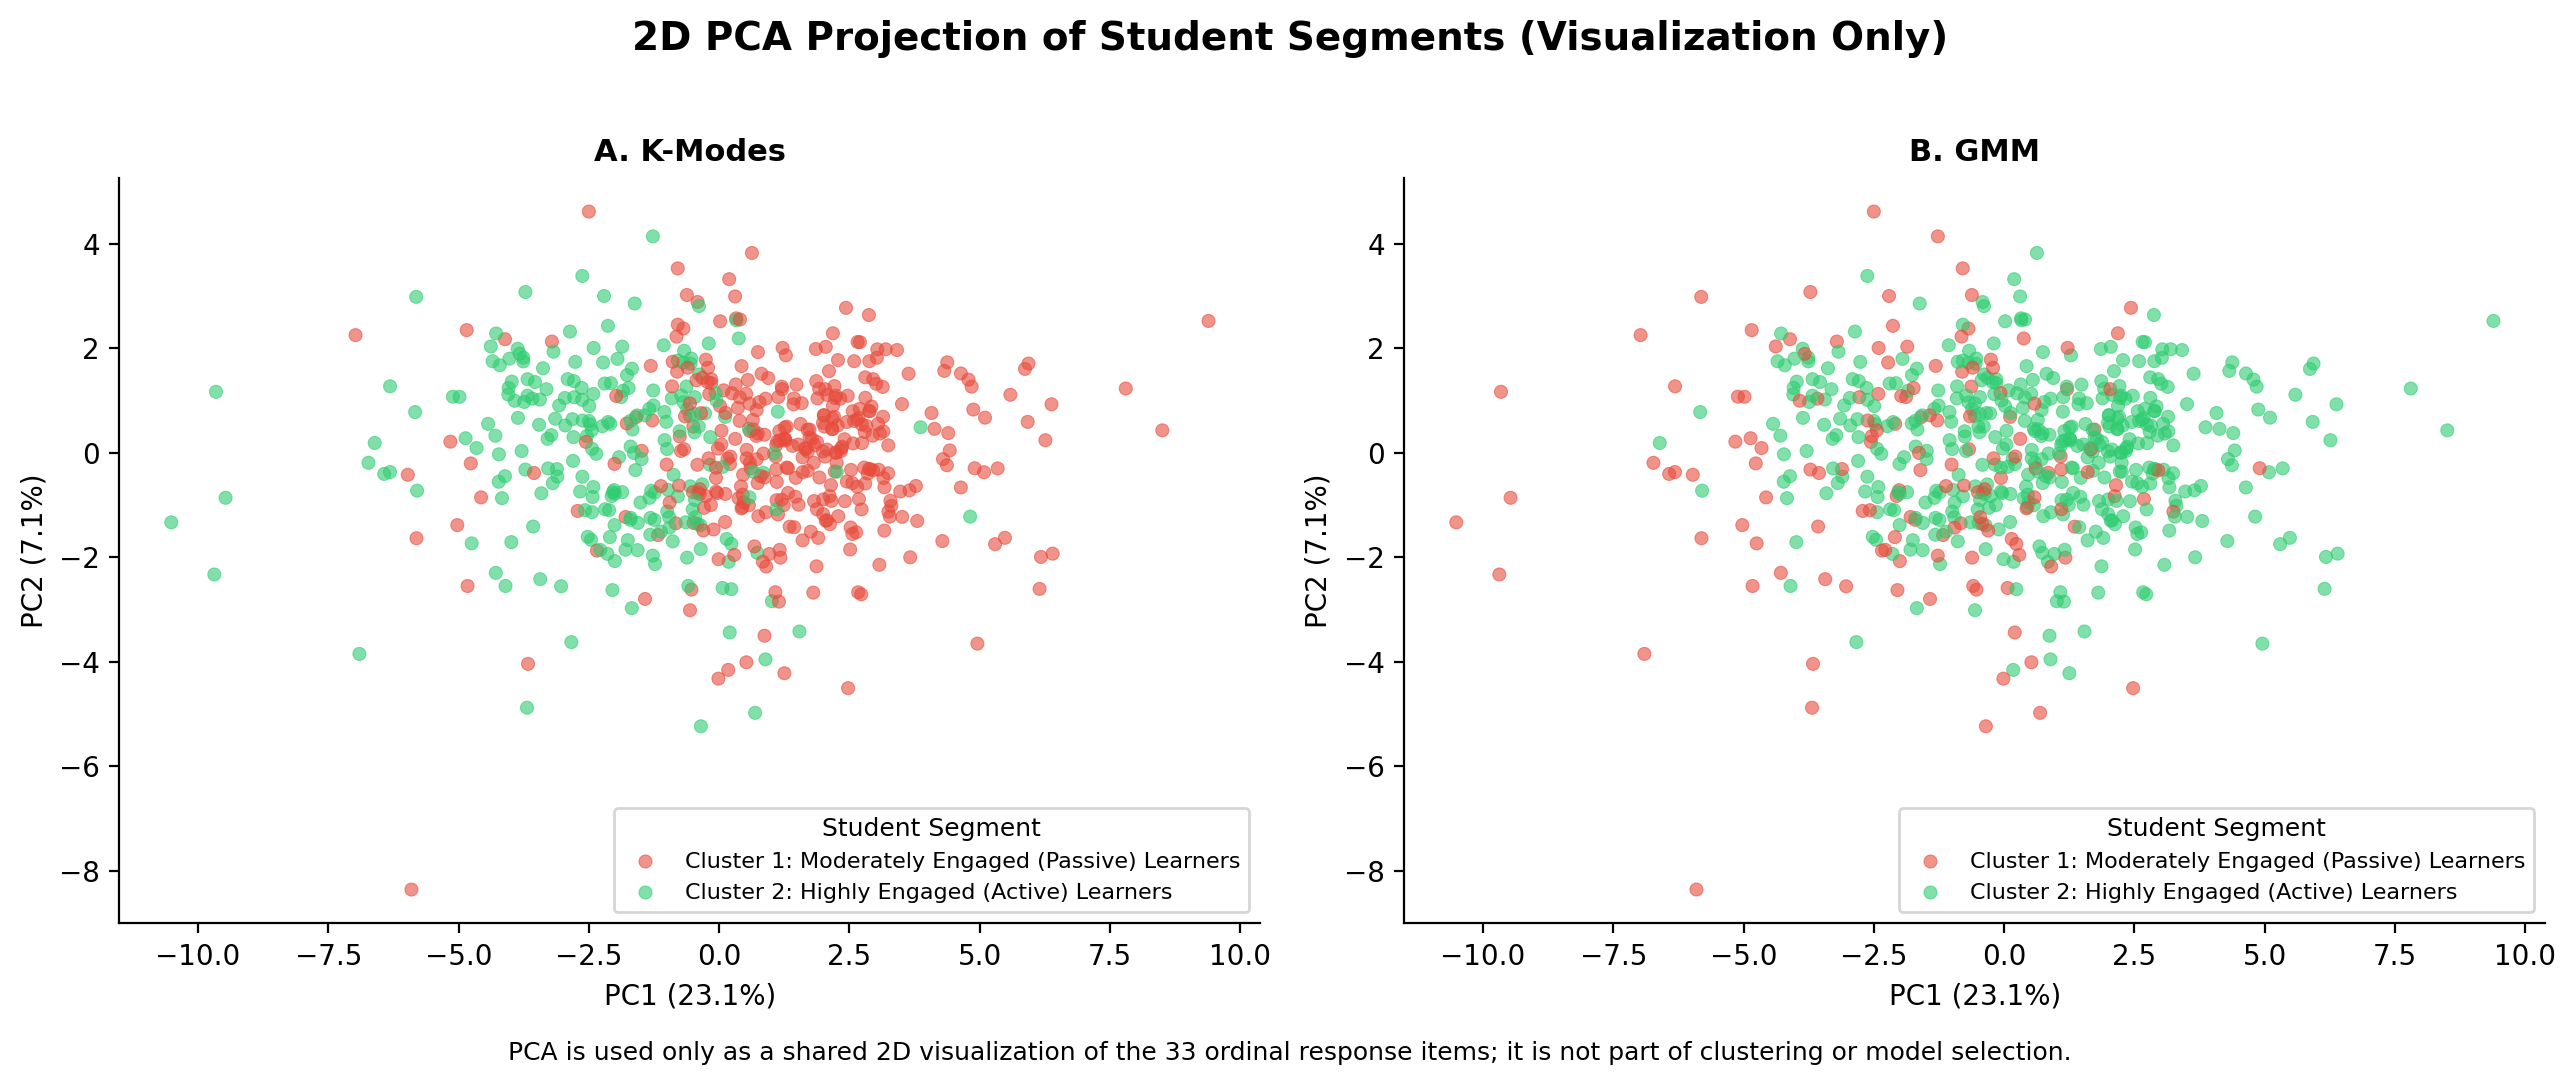

In [48]:
# ── PCA projection for visual comparison only ───────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Prepare data
X_pca_vis = df[cluster_vars].copy().dropna()
idx_vis = X_pca_vis.index

scaler = StandardScaler()
X_pca_sc = scaler.fit_transform(X_pca_vis)

# 2. PCA
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2.fit_transform(X_pca_sc)

# 3. Meaningful cluster labels
cluster_name_map = {
    1: "Cluster 1: Moderately Engaged (Passive) Learners",
    2: "Cluster 2: Highly Engaged (Active) Learners"
}

cluster_order = [
    "Cluster 1: Moderately Engaged (Passive) Learners",
    "Cluster 2: Highly Engaged (Active) Learners"
]

palette = {
    "Cluster 1: Moderately Engaged (Passive) Learners": "#e74c3c",
    "Cluster 2: Highly Engaged (Active) Learners": "#2ecc71"
}

# 4. Map labels
km_labels_clean = df.loc[idx_vis, "student_segment"].astype(int).map(cluster_name_map)
gmm_labels_clean = df.loc[idx_vis, "gmm_cluster_id"].astype(int).map(cluster_name_map)

# 5. DataFrame for visualization
vis_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "K-Modes": km_labels_clean,
    "GMM": gmm_labels_clean
})

# ── Plot ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

fig.suptitle(
    "2D PCA Projection of Student Segments (Visualization Only)",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

# A. K-Modes
sns.scatterplot(
    data=vis_df,
    x="PC1",
    y="PC2",
    hue="K-Modes",
    hue_order=cluster_order,
    palette=palette,
    s=22,
    alpha=0.60,
    edgecolor=None,
    ax=axes[0]
)

axes[0].set_title("A. K-Modes", fontsize=11, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].grid(False)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[0].legend(
    title="Student Segment",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

# B. GMM
sns.scatterplot(
    data=vis_df,
    x="PC1",
    y="PC2",
    hue="GMM",
    hue_order=cluster_order,
    palette=palette,
    s=22,
    alpha=0.60,
    edgecolor=None,
    ax=axes[1]
)

axes[1].set_title("B. GMM", fontsize=11, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].grid(False)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

axes[1].legend(
    title="Student Segment",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

# Footnote
fig.text(
    0.5,
    -0.02,
    "PCA is used only as a shared 2D visualization of the 33 ordinal response items; it is not part of clustering or model selection.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

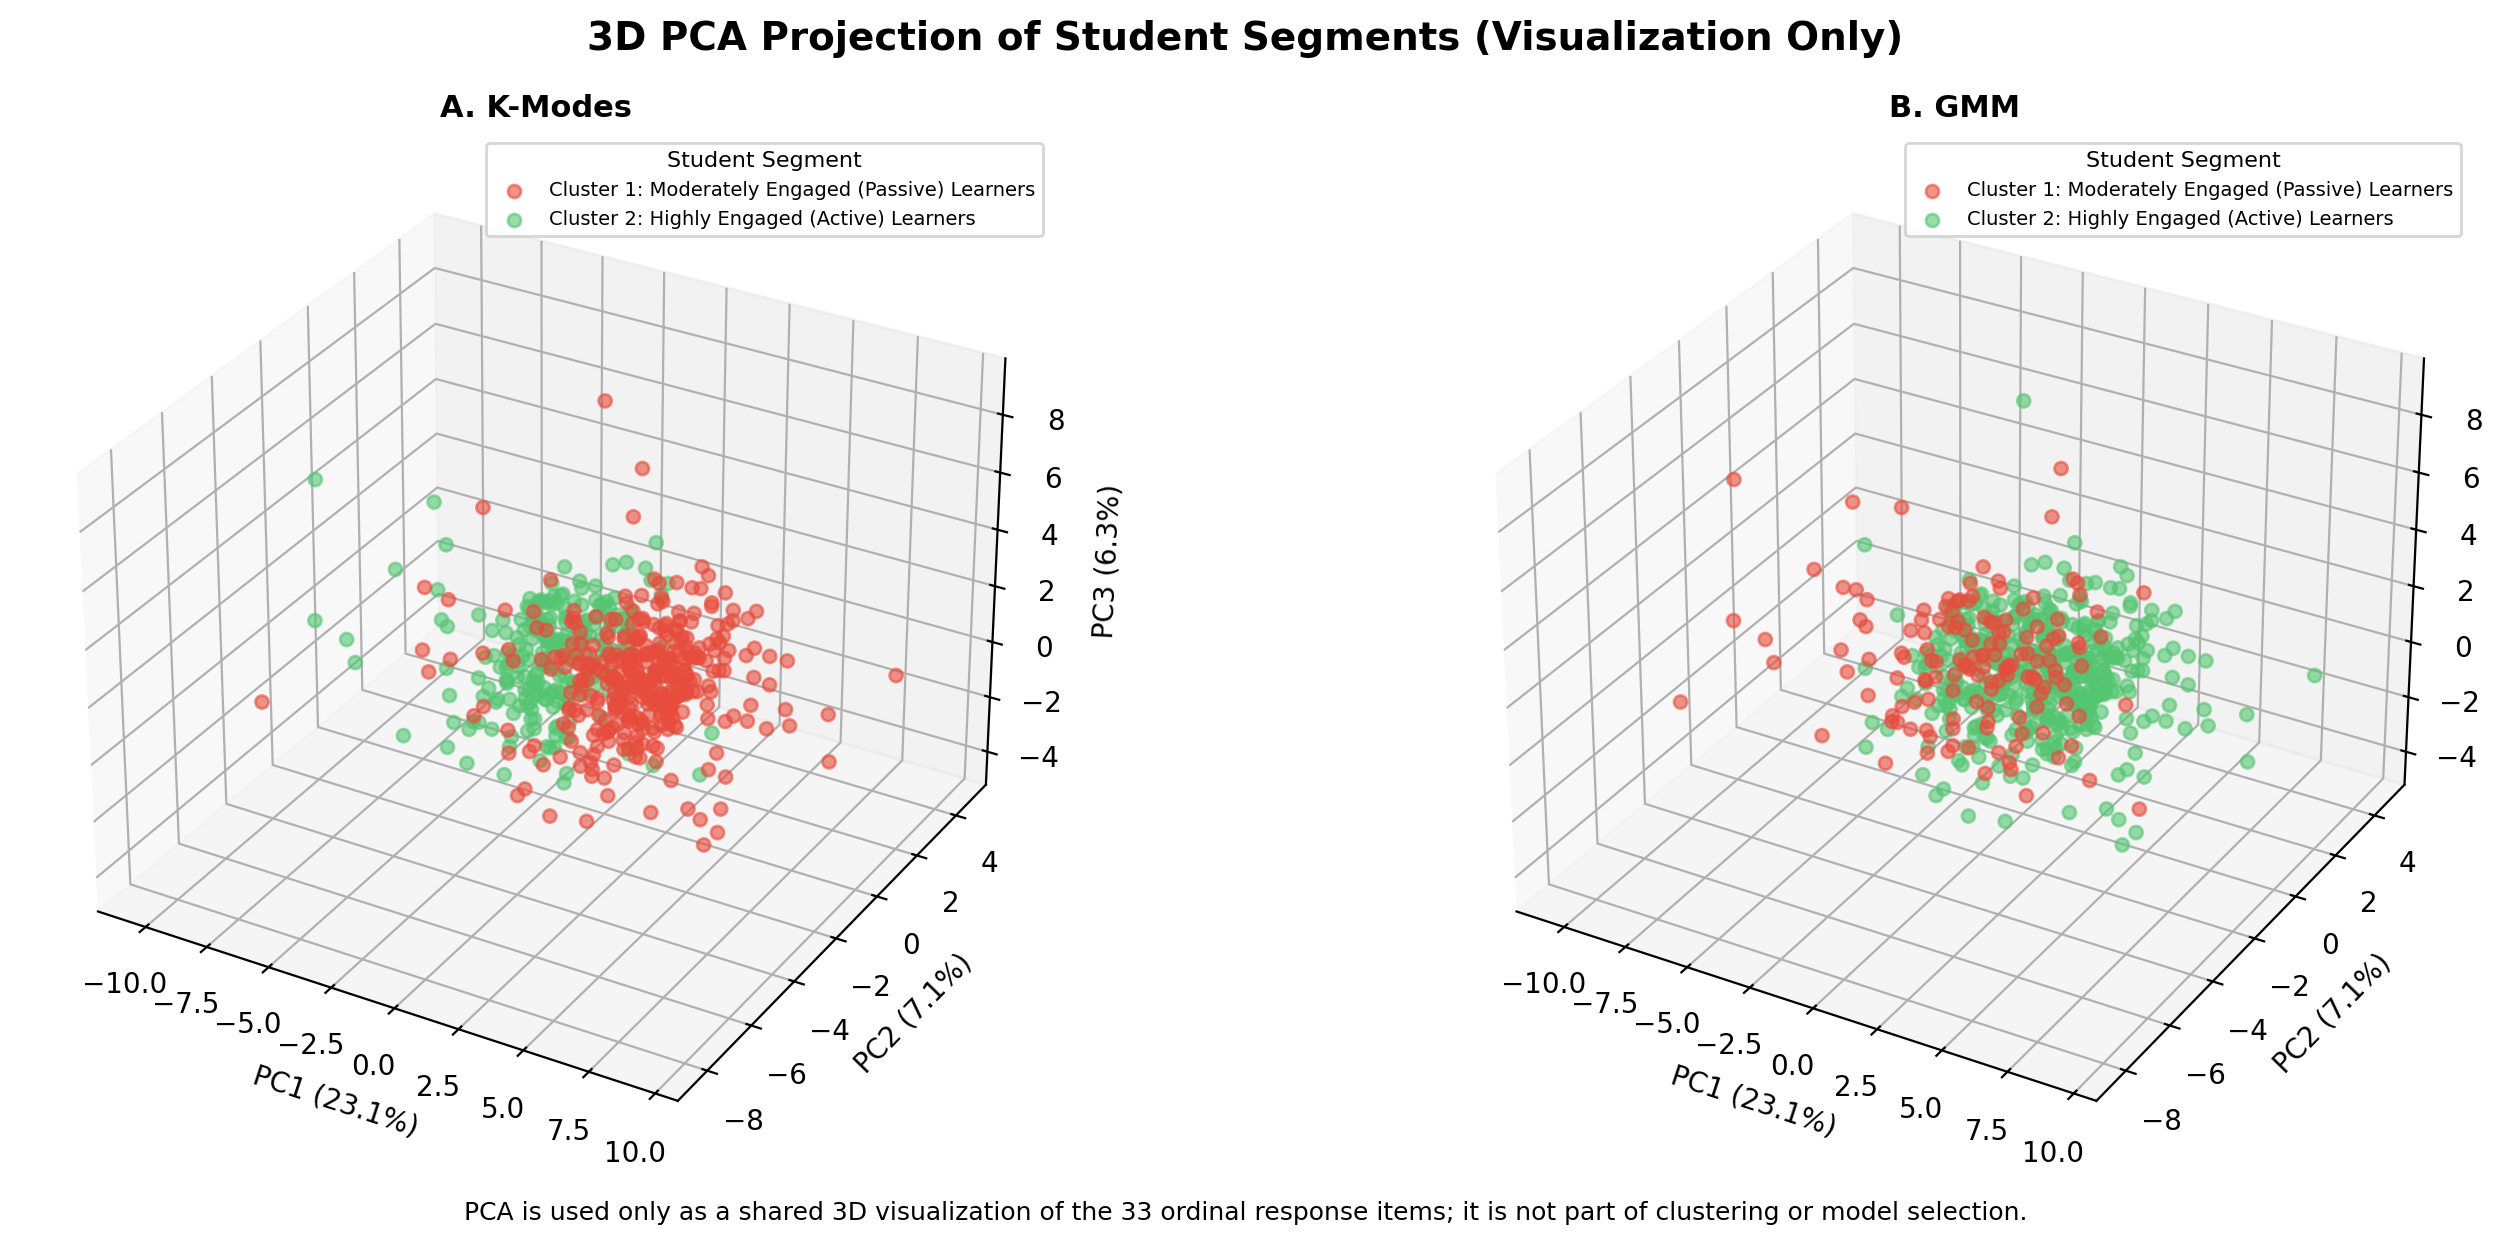

In [49]:
# ── 3D PCA projection for visual comparison only ─────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Prepare data
X_pca_vis = df[cluster_vars].copy().dropna()
idx_vis = X_pca_vis.index

scaler = StandardScaler()
X_pca_sc = scaler.fit_transform(X_pca_vis)

# 2. PCA with 3 components
pca_3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3.fit_transform(X_pca_sc)

# 3. Meaningful cluster labels
cluster_name_map = {
    1: "Cluster 1: Moderately Engaged (Passive) Learners",
    2: "Cluster 2: Highly Engaged (Active) Learners"
}

cluster_order = [
    "Cluster 1: Moderately Engaged (Passive) Learners",
    "Cluster 2: Highly Engaged (Active) Learners"
]

palette = {
    "Cluster 1: Moderately Engaged (Passive) Learners": "#e74c3c",
    "Cluster 2: Highly Engaged (Active) Learners": "#54C571"
}

# 4. Clean cluster labels
km_labels_clean = df.loc[idx_vis, "student_segment"].astype(int).map(cluster_name_map)
gmm_labels_clean = df.loc[idx_vis, "gmm_cluster_id"].astype(int).map(cluster_name_map)

# 5. DataFrame for visualization
vis_3d_df = pd.DataFrame({
    "PC1": X_pca_3d[:, 0],
    "PC2": X_pca_3d[:, 1],
    "PC3": X_pca_3d[:, 2],
    "K-Modes": km_labels_clean,
    "GMM": gmm_labels_clean
})

# ── Plot ───────────────────────────────
fig = plt.figure(figsize=(15, 6), dpi=200)

fig.suptitle(
    "3D PCA Projection of Student Segments (Visualization Only)",
    fontsize=14,
    fontweight="bold",
    y=0.98
)

# A. K-Modes
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

for cluster in cluster_order:
    subset = vis_3d_df[vis_3d_df["K-Modes"] == cluster]
    ax1.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        label=cluster,
        color=palette[cluster],
        s=22,
        alpha=0.60
    )

ax1.set_title("A. K-Modes", fontsize=11, fontweight="bold")
ax1.set_xlabel(f"PC1 ({pca_3.explained_variance_ratio_[0]*100:.1f}%)")
ax1.set_ylabel(f"PC2 ({pca_3.explained_variance_ratio_[1]*100:.1f}%)")
ax1.set_zlabel(f"PC3 ({pca_3.explained_variance_ratio_[2]*100:.1f}%)")

ax1.legend(
    title="Student Segment",
    fontsize=7,
    title_fontsize=8,
    frameon=True
)

# B. GMM
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

for cluster in cluster_order:
    subset = vis_3d_df[vis_3d_df["GMM"] == cluster]
    ax2.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        label=cluster,
        color=palette[cluster],
        s=22,
        alpha=0.60
    )

ax2.set_title("B. GMM", fontsize=11, fontweight="bold")
ax2.set_xlabel(f"PC1 ({pca_3.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({pca_3.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_zlabel(f"PC3 ({pca_3.explained_variance_ratio_[2]*100:.1f}%)")

ax2.legend(
    title="Student Segment",
    fontsize=7,
    title_fontsize=8,
    frameon=True
)

# Footnote
fig.text(
    0.5,
    -0.02,
    "PCA is used only as a shared 3D visualization of the 33 ordinal response items; it is not part of clustering or model selection.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

Why overlap exists?

Answer:

Because the data is behavioral and ordinal (Likert), student experiences are inherently continuous rather than sharply separable.

# Define segment labels from K-Modes and CA pairs

In [50]:
# Final segment labels from K-Modes
cluster_name_map = {
    1: 'Highly Engaged (Active) Learners',
    2: 'Moderately Engaged (Passive) Learners'
}
df['student_segment'] = km_labels
df['student_segment_label'] = df['student_segment'].map(cluster_name_map)

# Bin satisfaction for readability in CA
df['sat_bin'] = pd.cut(
    df['overall_satisfaction'],
    bins=[0, 2, 3, 5],
    labels=['Low (1-2)', 'Medium (3)', 'High (4-5)'],
    include_lowest=True
)

CA_PAIRS = [
    ('student_segment_label', 'gender', 'Student Segment × Gender'),
    ('student_segment_label', 'education_level', 'Student Segment × Education Level'),
    ('student_segment_label', 'ideal_balance', 'Student Segment × Ideal Blend'),
    ('student_segment_label', 'prefer_more_blended', 'Student Segment × Prefer More Blended'),
    ('student_segment_label', 'sat_bin', 'Student Segment × Satisfaction')
]

In [51]:
# ──  CA helper functions ────────────────────────────────────────────────
def run_ca(ctab, n_components=2, random_state=42):
    ca = prince.CA(
        n_components=n_components,
        n_iter=10,
        copy=True,
        engine="sklearn",
        random_state=random_state
    ).fit(ctab)

    row_c = ca.row_coordinates(ctab)
    col_c = ca.column_coordinates(ctab)

    # Explained inertia if available
    inertia = None
    try:
        eig = np.array(ca.eigenvalues_)
        if eig.sum() > 0:
            inertia = eig / eig.sum() * 100
    except Exception:
        pass

    return row_c, col_c, inertia


def shorten(label, maxlen=18):
    s = str(label)
    return s if len(s) <= maxlen else s[:maxlen] + '..'

In [52]:
# Contingency tables for reporting ───────────────────────────────────
for row_var, col_var, title in CA_PAIRS:
    sub = df[[row_var, col_var]].dropna()
    ctab = pd.crosstab(sub[row_var], sub[col_var], normalize='index') * 100
    print(f'\n=== {title} ===')
    display(ctab.round(1))


=== Student Segment × Gender ===


gender,Female,Male,Prefer Not To Say
student_segment_label,,,
Highly Engaged (Active) Learners,32.8,65.5,1.7
Moderately Engaged (Passive) Learners,32.5,66.2,1.3



=== Student Segment × Education Level ===


education_level,Master,Other,PHD,Year1 - Freshman,Year2 - Sophomore,Year3 - Junior,Year4 - Senior,Year5 - Final Year
student_segment_label,,,,,,,,
Highly Engaged (Active) Learners,4.2,1.4,0.3,3.4,50.7,16.0,14.3,9.8
Moderately Engaged (Passive) Learners,2.6,2.6,0.0,4.8,55.4,13.9,12.6,8.2



=== Student Segment × Ideal Blend ===


ideal_balance,"Balanced Half and Half (50% In-person, 50% Online)","More Face-to-Face than Online (e.g., 60% In-person, 40% Online)","More Online than Face-to-Face (e.g., 40% In-person, 60% Online)","Mostly Face-to-Face (e.g., 80% In-person, 20% Online)","Mostly Online (e.g., 20% In-person, 80% Online)"
student_segment_label,,,,,
Highly Engaged (Active) Learners,21.0,30.8,6.7,38.4,3.1
Moderately Engaged (Passive) Learners,21.2,25.5,5.6,44.6,3.0



=== Student Segment × Prefer More Blended ===


prefer_more_blended,Neutral/Unsure,No,Yes
student_segment_label,,,
Highly Engaged (Active) Learners,29.7,3.6,66.7
Moderately Engaged (Passive) Learners,58.9,6.1,35.1



=== Student Segment × Satisfaction ===


sat_bin,Low (1-2),Medium (3),High (4-5)
student_segment_label,,,
Highly Engaged (Active) Learners,5.6,23.8,70.6
Moderately Engaged (Passive) Learners,10.4,67.5,22.1


In [53]:
# Final segment labels
cluster_name_map = {
    1: 'Highly Engaged (Active) Learners',
    2: 'Moderately Engaged (Passive) Learners'
}

df['student_segment'] = km_labels
df['student_segment_label'] = df['student_segment'].map(cluster_name_map)

# Satisfaction bin for readability
df['sat_bin'] = pd.cut(
    df['overall_satisfaction'],
    bins=[0, 2, 3, 5],
    labels=['Low (1-2)', 'Medium (3)', 'High (4-5)'],
    include_lowest=True
)

BAR_VARS = [
    ('sat_bin', 'Satisfaction'),
    ('ideal_balance', 'Ideal Blended Learning Balance'),
    ('prefer_more_blended', 'Preference for More Blended Learning')
]

In [54]:
# ──  Helper to build 100% stacked tables ─────────────────────────────────
def row_pct_table(df, row_var, col_var):
    tab = pd.crosstab(df[row_var], df[col_var], normalize='index') * 100
    return tab.round(1)

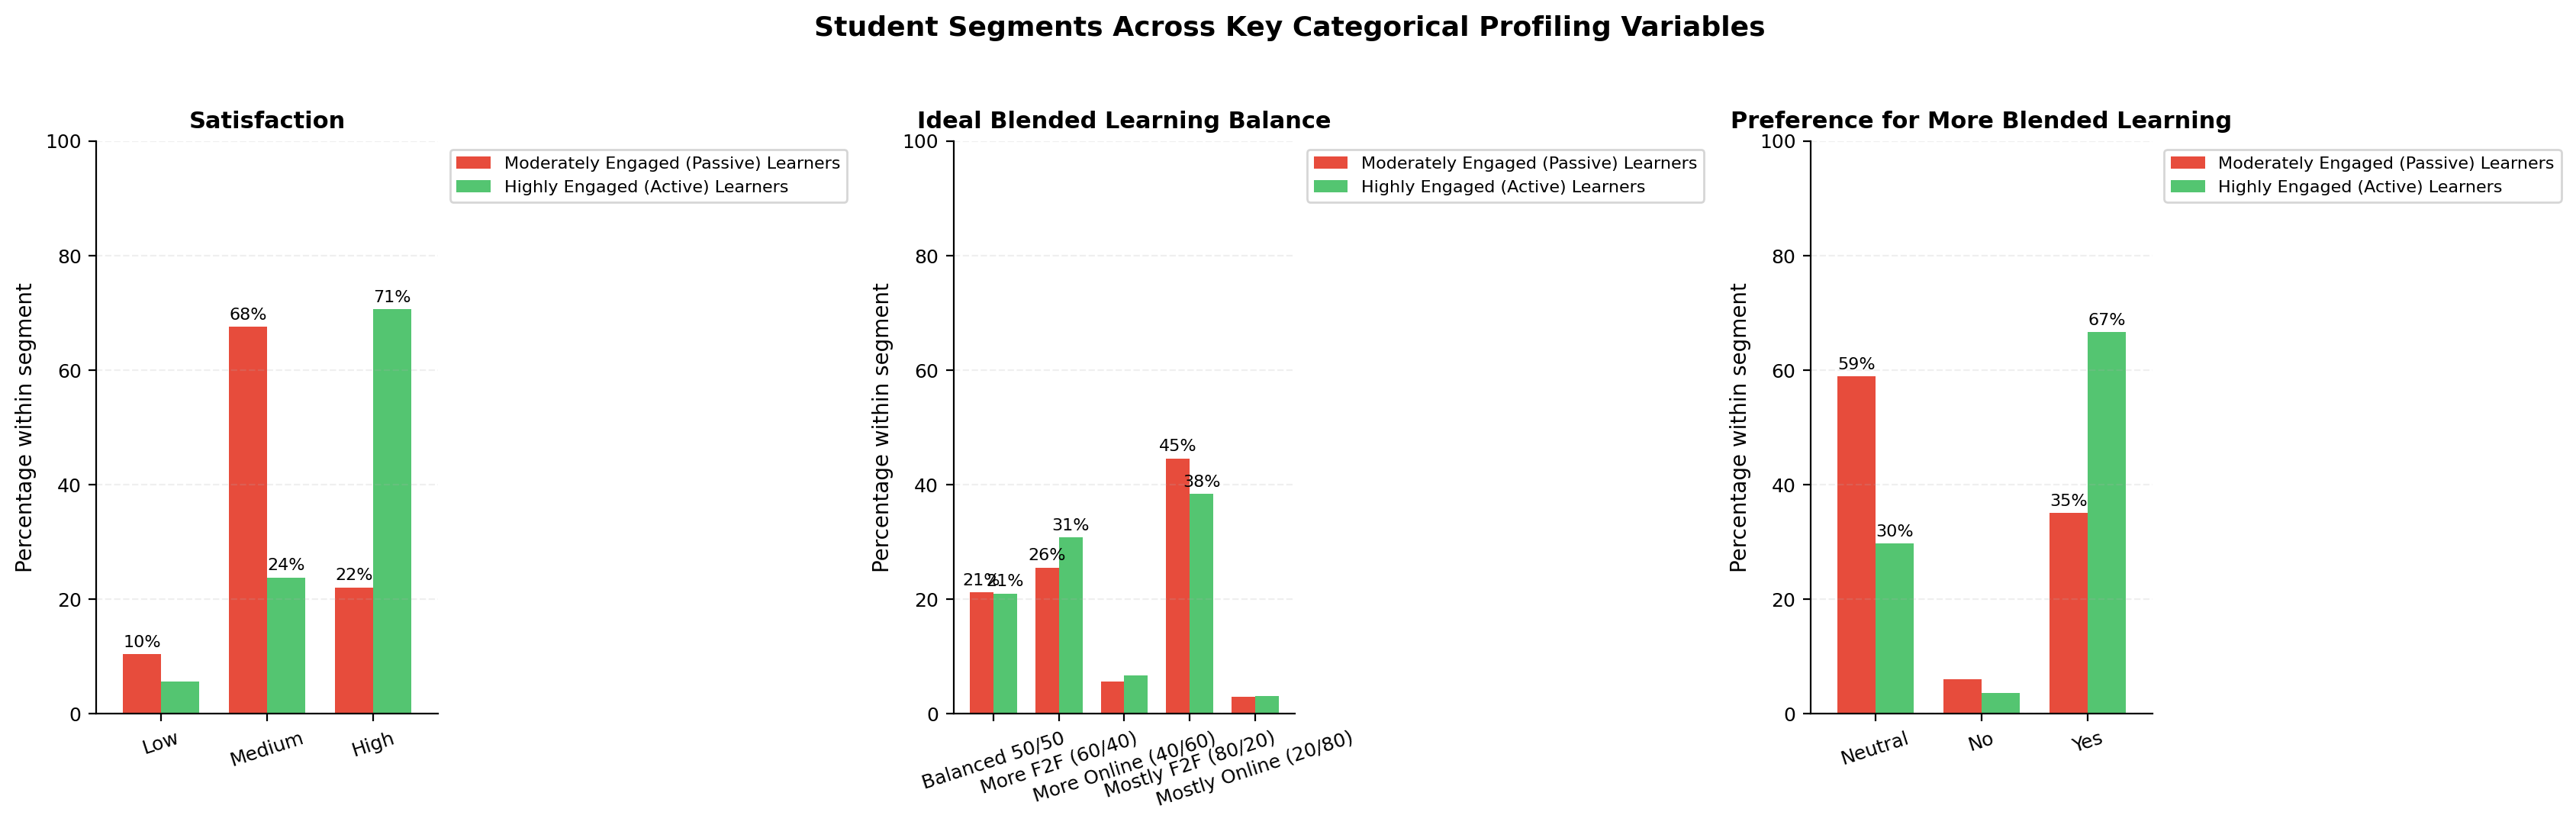

In [55]:
# ──  Improved grouped bar charts (thesis-ready) ─────────────────────────

# Shorter display labels for readability
ideal_balance_map = {
    'Balanced Half and Half (50% In-person, 50% Online)': 'Balanced 50/50',
    'More Face-to-Face than Online (e.g., 60% In-person, 40% Online)': 'More F2F (60/40)',
    'More Online than Face-to-Face (e.g., 40% In-person, 60% Online)': 'More Online (40/60)',
    'Mostly Face-to-Face (e.g., 80% In-person, 20% Online)': 'Mostly F2F (80/20)',
    'Mostly Online (e.g., 20% In-person, 80% Online)': 'Mostly Online (20/80)'
}

sat_bin_map = {
    'Low (1-2)': 'Low',
    'Medium (3)': 'Medium',
    'High (4-5)': 'High'
}

prefer_map = {
    'Neutral/Unsure': 'Neutral',
    'No': 'No',
    'Yes': 'Yes'
}

display_maps = {
    'sat_bin': sat_bin_map,
    'ideal_balance': ideal_balance_map,
    'prefer_more_blended': prefer_map
}

segment_order = ['Moderately Engaged (Passive) Learners', 'Highly Engaged (Active) Learners']
segment_colors = ['#e74c3c', '#54C571']  # red, green

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), dpi=200)
fig.suptitle(
    'Student Segments Across Key Categorical Profiling Variables',
    fontsize=13,
    fontweight='bold',
    y=1.03
)

for ax, (var, title) in zip(axes, BAR_VARS):
    sub = df[['student_segment_label', var]].dropna().copy()

    # Apply shorter category labels if available
    if var in display_maps:
        sub[var] = sub[var].map(lambda x: display_maps[var].get(x, x))

    tab = pd.crosstab(sub[var], sub['student_segment_label'], normalize='columns') * 100
    tab = tab[[c for c in segment_order if c in tab.columns]]

    tab.plot(
        kind='bar',
        ax=ax,
        width=0.72,
        color=segment_colors
    )

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage within segment')
    ax.set_ylim(0, 100)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', alpha=0.20, linestyle='--')

    ax.tick_params(axis='x', rotation=18, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    # Legend outside panel
    ax.legend(
        title='',
        fontsize=8,
        frameon=True,
        loc='upper left',
        bbox_to_anchor=(1.01, 1.0)
    )

    # Add value labels only for bars >= 8% to avoid clutter
    for container in ax.containers:
        labels = []
        for bar in container:
            h = bar.get_height()
            labels.append(f'{h:.0f}%' if h >= 8 else '')
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)

plt.tight_layout()
plt.show()

# SAVE CLEANED DATASET WITH CLUSTERING RESULT

In [56]:
df["student_segment"] = km_labels
df["student_segment_label"] = df["student_segment"].map(cluster_name_map)

df.to_csv(
    settings.path["output_cluster_path"],
    index=False,
    encoding="utf-8-sig"
)

print(f"Dataset with clustering results saved to: {settings.path['output_cluster_path']}")
print(f"Final shape: {df.shape}")

print("\nCluster counts:")
print(df["student_segment_label"].value_counts())

Dataset with clustering results saved to: C:\Users\Tepy\Documents\tepy\Final Internship Docs\blended_learning\data\processed\cluster_data.csv
Final shape: (588, 95)

Cluster counts:
student_segment_label
Highly Engaged (Active) Learners         357
Moderately Engaged (Passive) Learners    231
Name: count, dtype: int64
